# 02. EDA and Data Quality

## 1. Purpose of Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to understand the structure, distributions, relationships, and data-quality characteristics of the training data before preprocessing and model development.

The analysis focuses on identifying useful patterns, unusual observations, missing-data patterns, and potential issues that may affect regression models.

## 2. Import Required Libraries

The required Python libraries are imported for data manipulation, numerical analysis, visualization, and project file handling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 3. Load the Raw Dataset and Training Indices

The raw dataset and the previously saved training indices are loaded to reconstruct the exact training dataset used for EDA.

In [2]:
project_root = Path.cwd().parent

data_path = project_root / "data" / "raw" / "melb_data.csv"
train_index_path = project_root / "data" / "processed" / "train_indices.csv"

df = pd.read_csv(data_path)
train_indices = pd.read_csv(train_index_path)["row_index"]

train_df = df.loc[train_indices].copy()

print("Full dataset:", df.shape)
print("Training dataset:", train_df.shape)

Full dataset: (13580, 21)
Training dataset: (10864, 21)


### Observation

The raw dataset contains 13,580 rows and 21 columns. Using the saved training indices successfully reconstructed the training dataset with 10,864 rows and 21 columns. The same fixed training split will be used throughout the EDA process.

## 4. Inspect the Training Data Structure

The training dataset is inspected for its columns, data types, and non-null counts before detailed exploratory analysis.

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10864 entries, 12796 to 7270
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         10864 non-null  object 
 1   Address        10864 non-null  object 
 2   Rooms          10864 non-null  int64  
 3   Type           10864 non-null  object 
 4   Price          10864 non-null  float64
 5   Method         10864 non-null  object 
 6   SellerG        10864 non-null  object 
 7   Date           10864 non-null  object 
 8   Distance       10864 non-null  float64
 9   Postcode       10864 non-null  float64
 10  Bedroom2       10864 non-null  float64
 11  Bathroom       10864 non-null  float64
 12  Car            10814 non-null  float64
 13  Landsize       10864 non-null  float64
 14  BuildingArea   5735 non-null   float64
 15  YearBuilt      6578 non-null   float64
 16  CouncilArea    9774 non-null   object 
 17  Lattitude      10864 non-null  float64
 18  Longtitu

### Observation

The reconstructed training dataset contains 10,864 rows and 21 columns, including 12 `float64`, 1 `int64`, and 8 `object` columns. Missing values remain in `Car`, `BuildingArea`, `YearBuilt`, and `CouncilArea`, with `BuildingArea` and `YearBuilt` having substantial missingness. The non-sequential index values are expected because the training set was created using a randomized split while preserving the original dataset indices.

## 5. Identify Numerical and Categorical Features

Numerical and categorical features require different exploratory analysis. Numerical variables will be examined through distributions, skewness, outliers, and relationships, while categorical variables will be examined through category frequencies and cardinality.

In [4]:
numerical_features = train_df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = train_df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Rooms', 'Price', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount']

Categorical features:
['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 'CouncilArea', 'Regionname']


### Observation

The training dataset contains 13 numerical columns and 8 object columns based on their current data types. `Price` is included among the numerical columns but represents the target variable rather than a predictor. Some columns require semantic consideration: `Postcode` is numerically stored but acts as a location identifier, while `Date` is stored as an object but represents temporal information. Their final treatment will be decided during feature engineering and preprocessing.

## 6. Examine the Target Variable

The distribution and descriptive statistics of `Price` are examined before analysing the predictor variables. This helps identify the target range, central tendency, variability, and possible skewness.

In [5]:
price_summary = train_df["Price"].describe()
price_skewness = train_df["Price"].skew()

print(
    price_summary.to_string(
        float_format=lambda value: f"{value:,.2f}"
    )
)

print(f"\nPrice skewness: {price_skewness:.4f}")

count      10,864.00
mean    1,074,964.93
std       641,554.34
min        85,000.00
25%       650,000.00
50%       905,000.00
75%     1,328,000.00
max     9,000,000.00

Price skewness: 2.2959


### Observation

The training target has a mean price of 1,074,964.93 and a median price of 905,000. The mean being higher than the median indicates that expensive properties are pulling the distribution towards the right. The skewness value of 2.2959 confirms a strongly right-skewed distribution. The maximum price of 9,000,000 is also substantially higher than the third quartile of 1,328,000. The distribution will be visualized before deciding whether a target transformation is appropriate.

## 7. Visualize the Target Distribution

A histogram and box plot are used to examine the shape, concentration, upper tail, and potentially extreme values of the target variable.

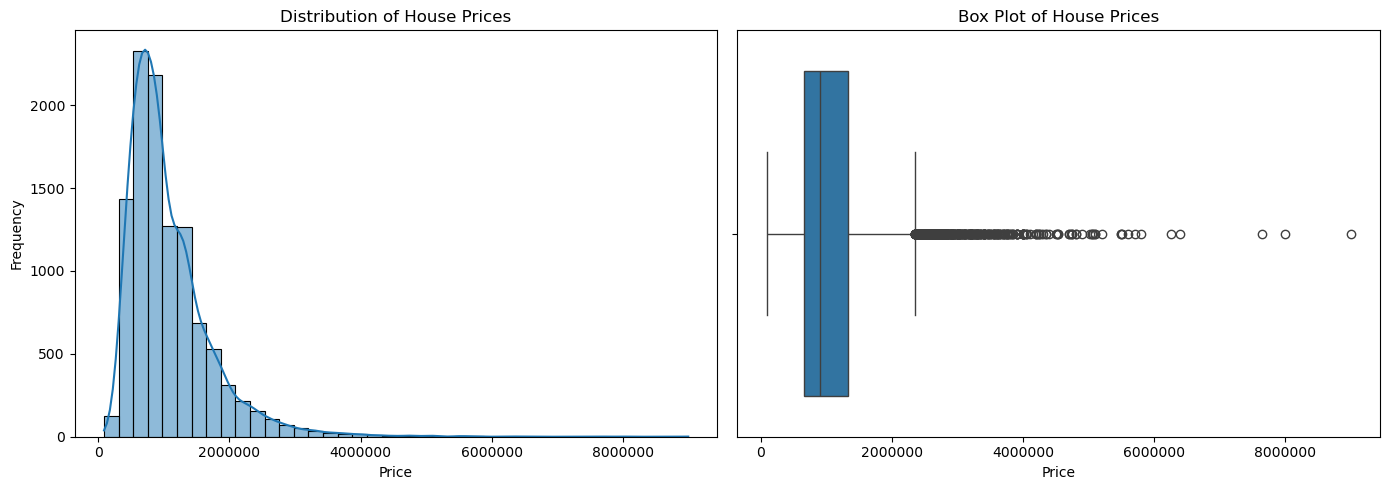

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=train_df,
    x="Price",
    bins=40,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Distribution of House Prices")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Frequency")
axes[0].ticklabel_format(style="plain", axis="x")

sns.boxplot(
    data=train_df,
    x="Price",
    ax=axes[1]
)

axes[1].set_title("Box Plot of House Prices")
axes[1].set_xlabel("Price")
axes[1].ticklabel_format(style="plain", axis="x")

plt.tight_layout()
figures_path = project_root / "results" / "figures"
figures_path.mkdir(parents=True, exist_ok=True)

plt.savefig(
    figures_path / "price_distribution_and_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### Observation

The histogram confirms that house prices are strongly right-skewed, with most observations concentrated in the lower and middle price ranges and a long upper tail extending to 9,000,000. The box plot identifies numerous high-price observations beyond the upper whisker. These observations are statistical outliers, but they are not automatically data errors because they may represent genuine luxury properties. They will be quantified and investigated before any treatment decision is made.

## 8. Quantify Potential Target Outliers

The Interquartile Range (IQR) method is used to quantify unusually low or high house prices. Values outside 1.5 times the IQR are treated as potential statistical outliers for investigation, not automatically as data errors.

In [7]:
q1 = train_df["Price"].quantile(0.25)
q3 = train_df["Price"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

lower_outliers = (train_df["Price"] < lower_bound).sum()
upper_outliers = (train_df["Price"] > upper_bound).sum()

total_outliers = lower_outliers + upper_outliers
outlier_percentage = (total_outliers / len(train_df)) * 100

print(f"Q1: {q1:,.2f}")
print(f"Q3: {q3:,.2f}")
print(f"IQR: {iqr:,.2f}")
print(f"Lower boundary: {lower_bound:,.2f}")
print(f"Upper boundary: {upper_bound:,.2f}")
print(f"Lower-price potential outliers: {lower_outliers:,}")
print(f"Upper-price potential outliers: {upper_outliers:,}")
print(f"Total potential outliers: {total_outliers:,}")
print(f"Potential outlier percentage: {outlier_percentage:.2f}%")

Q1: 650,000.00
Q3: 1,328,000.00
IQR: 678,000.00
Lower boundary: -367,000.00
Upper boundary: 2,345,000.00
Lower-price potential outliers: 0
Upper-price potential outliers: 496
Total potential outliers: 496
Potential outlier percentage: 4.57%


### Observation

The IQR of house prices is 678,000, producing a lower boundary of -367,000 and an upper boundary of 2,345,000. No observations fall below the lower boundary, while 496 properties exceed the upper boundary. These high-price observations represent 4.57% of the training data. They are potential statistical outliers but are not automatically data errors or influential model observations. They will be investigated further and retained until model residuals and influence diagnostics provide stronger evidence.

## 9. Inspect High-Price Observations

The most expensive properties are inspected using relevant structural and location features. This helps determine whether the high prices appear to represent plausible luxury properties or obvious data-quality problems.

In [8]:
inspection_columns = [
    "Suburb",
    "Rooms",
    "Type",
    "Price",
    "Distance",
    "Bathroom",
    "Landsize",
    "BuildingArea",
    "YearBuilt",
    "Regionname"
]

high_price_properties = (
    train_df.loc[
        train_df["Price"] > upper_bound,
        inspection_columns
    ]
    .sort_values("Price", ascending=False)
)

high_price_properties.head(10)

,Suburb,Rooms,Type,Price,Distance,Bathroom,Landsize,BuildingArea,YearBuilt,Regionname
12094,Mulgrave,3,h,9000000.0,18.8,1.0,744.0,117.0,1960.0,South-Eastern Metropolitan
7692,Canterbury,5,h,8000000.0,9.0,5.0,2079.0,464.3,1880.0,Southern Metropolitan
9575,Hawthorn,4,h,7650000.0,5.3,2.0,1690.0,284.0,1863.0,Southern Metropolitan
12557,Middle Park,5,h,6400000.0,3.0,2.0,553.0,308.0,1920.0,Southern Metropolitan
6372,Toorak,3,h,6250000.0,4.6,3.0,564.0,342.0,2000.0,Southern Metropolitan
7554,Brighton,5,h,5800000.0,11.2,4.0,1276.0,NaN,1880.0,Southern Metropolitan
5631,South Yarra,4,h,5700000.0,3.3,2.0,292.0,272.0,1880.0,Southern Metropolitan
9233,Middle Park,6,h,5600000.0,3.0,4.0,472.0,328.0,1915.0,Southern Metropolitan
9179,Hawthorn,5,h,5510000.0,5.3,2.0,820.0,300.0,1971.0,Southern Metropolitan
12239,Brighton,5,h,5500000.0,10.5,5.0,830.0,NaN,NaN,Southern Metropolitan


### Observation

Most of the highest-priced observations appear potentially plausible because they are houses located mainly in the Southern Metropolitan region and often contain large land areas, building areas, or multiple rooms and bathrooms. Nine of the ten most expensive properties belong to the Southern Metropolitan region, highlighting the possible importance of location. However, the 9,000,000 Mulgrave property appears unusual relative to its visible structural features and requires a within-suburb comparison before determining whether it is a genuine luxury observation or a possible data-quality anomaly. No observations are removed at this stage.

## 10. Investigate the Highest-Priced Property

The highest-priced Mulgrave property is compared with other properties from the same suburb. A within-suburb comparison provides a more meaningful assessment because house prices are strongly affected by location.

In [9]:
mulgrave_columns = [
    "Address",
    "Rooms",
    "Type",
    "Price",
    "Method",
    "Distance",
    "Bedroom2",
    "Bathroom",
    "Car",
    "Landsize",
    "BuildingArea",
    "YearBuilt"
]

mulgrave_properties = (
    train_df.loc[
        train_df["Suburb"] == "Mulgrave",
        mulgrave_columns
    ]
    .sort_values("Price", ascending=False)
)

print("Number of Mulgrave properties:", len(mulgrave_properties))
print(f"Median Mulgrave price: {mulgrave_properties['Price'].median():,.2f}")
print(f"Mean Mulgrave price: {mulgrave_properties['Price'].mean():,.2f}")

mulgrave_properties.head(10)

Number of Mulgrave properties: 26
Median Mulgrave price: 894,500.00
Mean Mulgrave price: 1,251,653.85


,Address,Rooms,Type,Price,Method,Distance,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt
12094,35 Bevis St,3,h,9000000.0,PI,18.8,3.0,1.0,1.0,744.0,117.0,1960.0
9647,10 Adela Ct,4,h,2000000.0,S,18.8,4.0,4.0,2.0,905.0,446.0,NaN
13241,9 Caledonia Cr,3,h,1105000.0,S,18.8,3.0,2.0,2.0,843.0,NaN,NaN
12361,63 Haverbrack Dr,4,h,1105000.0,S,18.8,4.0,3.0,2.0,650.0,224.0,1985.0
12799,1 Sneddon Ct,4,h,1100000.0,S,18.8,4.0,2.0,2.0,748.0,152.0,1996.0
10769,3 Catesby Cl,5,h,1016000.0,SP,18.8,5.0,2.0,2.0,873.0,NaN,NaN
12095,5 Grainger Ct,3,h,1001000.0,S,18.8,3.0,1.0,2.0,727.0,168.0,1970.0
11132,95 Wanda St,4,h,1001000.0,SP,18.8,4.0,2.0,7.0,771.0,NaN,NaN
11448,27 Glencairn St,5,h,960000.0,S,18.8,5.0,2.0,1.0,731.0,130.0,1965.0
13505,2229 Dandenong Rd,3,h,940000.0,S,18.8,3.0,2.0,3.0,709.0,140.0,1958.0


### Observation

Mulgrave contains 26 training properties with a median price of 894,500 and a mean price of 1,251,653.85. The highest-priced property is valued at 9,000,000, which is 4.5 times the second-highest Mulgrave price and approximately 10 times the suburb median. Its visible structural characteristics are also less substantial than those of several lower-priced properties. This makes it a suspected data-quality anomaly, but not a confirmed error. It will remain flagged for further verification rather than being removed automatically.

## 11. Measure the Influence of the Highest Mulgrave Price

A sensitivity calculation compares the mean Mulgrave price with and without its highest-priced observation. This measures how strongly one extreme value affects the arithmetic mean. The original training data is not modified.

In [10]:
highest_price_index = mulgrave_properties["Price"].idxmax()

highest_mulgrave_price = mulgrave_properties.loc[
    highest_price_index,
    "Price"
]

mean_with_highest = mulgrave_properties["Price"].mean()

mean_without_highest = (
    mulgrave_properties
    .drop(index=highest_price_index)["Price"]
    .mean()
)

mean_increase = mean_with_highest - mean_without_highest

percentage_increase = (
    mean_increase / mean_without_highest
) * 100

print(f"Highest Mulgrave price: {highest_mulgrave_price:,.2f}")
print(f"Mean with highest price: {mean_with_highest:,.2f}")
print(f"Mean without highest price: {mean_without_highest:,.2f}")
print(f"Increase in mean: {mean_increase:,.2f}")
print(f"Percentage increase in mean: {percentage_increase:.2f}%")

Highest Mulgrave price: 9,000,000.00
Mean with highest price: 1,251,653.85
Mean without highest price: 941,720.00
Increase in mean: 309,933.85
Percentage increase in mean: 32.91%


### Observation

Including the highest-priced Mulgrave property produces a mean price of 1,251,653.85. Temporarily excluding this observation reduces the mean to 941,720.00, a difference of 309,933.85 or 32.91%. This confirms that the observation strongly influences the suburb-level arithmetic mean. However, sensitivity of the mean does not prove that the recorded price is incorrect or justify automatic removal. The observation will remain flagged for later verification and model-based influence analysis.

### 12.1 Compare Original and Log-Transformed Price Skewness

A temporary log-transformed version of `Price` is created to determine whether the transformation reduces the strong right skewness. The original target column remains unchanged.

In [11]:
log_price = np.log1p(train_df["Price"])

print(f"Original Price skewness: {train_df['Price'].skew():.4f}")
print(f"Log Price skewness: {log_price.skew():.4f}")

Original Price skewness: 2.2959
Log Price skewness: 0.1776


### Observation

The original `Price` distribution has a strong positive skewness of 2.2959. Applying `log1p()` reduces the skewness to 0.1776, representing an approximate reduction of 92.26%. The transformed target is substantially more symmetric, indicating that a log-target model is worth investigating. However, reduced skewness alone does not prove normality or guarantee better predictive performance. Raw-target and log-target models will therefore be compared using training-data cross-validation, with final metrics calculated on the original price scale.

### 12.2 Visual Comparison of Original and Log-Transformed Prices

The original and log-transformed target distributions are visualized side by side. This confirms whether the numerical reduction in skewness is also visible in the distribution shape.

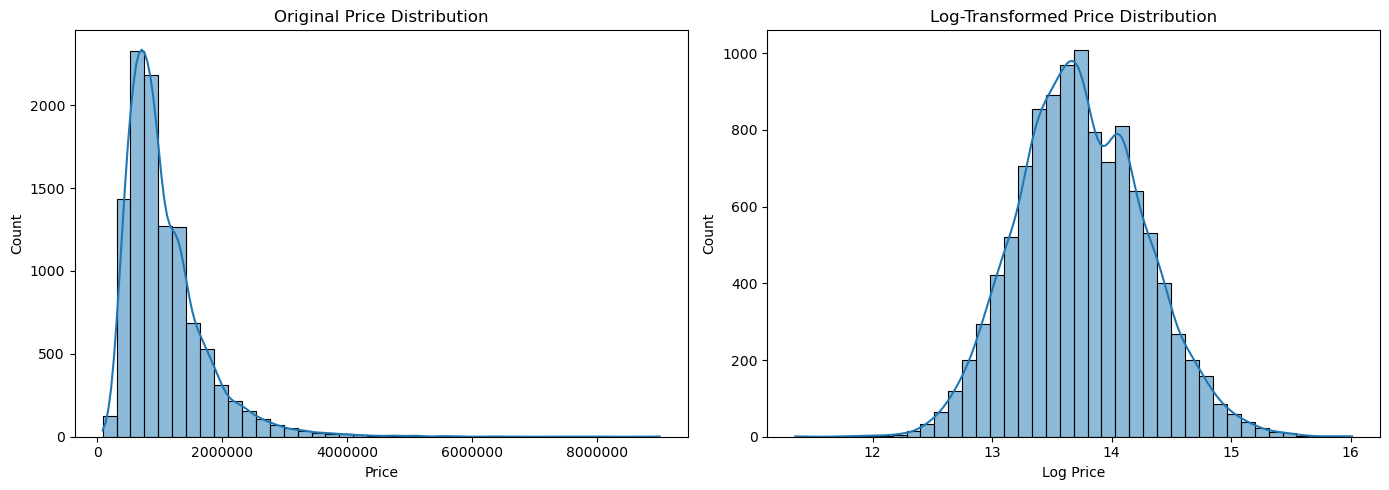

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train_df["Price"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Original Price Distribution")
axes[0].ticklabel_format(style="plain", axis="x")

sns.histplot(log_price, bins=40, kde=True, ax=axes[1])
axes[1].set_title("Log-Transformed Price Distribution")
axes[1].set_xlabel("Log Price")

plt.tight_layout()

plt.savefig(
    figures_path / "original_vs_log_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The original target distribution is strongly right-skewed, with most properties concentrated in the lower price range and a long upper tail extending to 9,000,000. After applying `log1p`, the observations become more evenly distributed and the shape becomes approximately symmetric. This visual improvement agrees with the reduction in skewness from 2.2959 to 0.1776. The transformed distribution is not assumed to be perfectly normal, but `log1p(Price)` is retained as a strong modelling candidate. The final choice between raw and log-transformed targets will be based on training cross-validation and evaluation in the original price scale.

### 13.1 Summarize Numerical Predictors

Descriptive statistics are calculated for the numerical predictor variables. This provides an initial view of their valid counts, central values, spread, ranges, and potentially unusual minimum or maximum values.

In [13]:
numerical_predictors = (
    train_df
    .select_dtypes(include="number")
    .columns
    .drop(["Price", "Postcode"])
)

numerical_summary = (
    train_df[numerical_predictors]
    .describe()
    .T
    .round(2)
)

numerical_summary

,count,mean,std,min,25%,50%,75%,max
Rooms,10864.0,2.94,0.96,1.00,2.00,3.0,3.00,10.00
Distance,10864.0,10.10,5.89,0.00,6.10,9.2,13.00,48.10
Bedroom2,10864.0,2.91,0.97,0.00,2.00,3.0,3.00,20.00
Bathroom,10864.0,1.53,0.69,0.00,1.00,1.0,2.00,8.00
Car,10814.0,1.61,0.96,0.00,1.00,2.0,2.00,10.00
Landsize,10864.0,524.16,1380.50,0.00,175.00,435.0,650.25,75100.00
BuildingArea,5735.0,154.00,601.70,0.00,92.00,126.0,175.00,44515.00
YearBuilt,6578.0,1965.10,36.37,1830.00,1940.00,1970.0,2000.00,2018.00
Lattitude,10864.0,-37.81,0.08,-38.18,-37.86,-37.8,-37.76,-37.41
Longtitude,10864.0,144.99,0.10,144.43,144.93,145.0,145.06,145.53


### Observation

The numerical summary reveals several data-quality characteristics. `Car` contains 50 missing values, `BuildingArea` contains 5,129, and `YearBuilt` contains 4,286. Potentially unusual zero values occur in several structural features. Extreme maximum values are present in `Bedroom2`, `Landsize`, and particularly `BuildingArea`, whose maximum of 44,515 is substantially larger than its median of 126. Geographic coordinates and the observed construction-year range appear broadly plausible. These findings require targeted investigation before preprocessing decisions are made.

### 14.1 Quantify Missing Values in the Training Data

Missing-value counts and percentages are calculated using only the training data. The columns are ordered from the highest to the lowest missing percentage to identify the most serious data-completeness issues.

In [14]:
train_missing = pd.DataFrame({
    "Missing Count": train_df.isna().sum(),
    "Missing Percentage": train_df.isna().mean() * 100
})

train_missing = (
    train_missing[train_missing["Missing Count"] > 0]
    .sort_values("Missing Percentage", ascending=False)
)

train_missing.round(2)

,Missing Count,Missing Percentage
BuildingArea,5129,47.21
YearBuilt,4286,39.45
CouncilArea,1090,10.03
Car,50,0.46


### Observation

Four training-data columns contain missing values. `BuildingArea` has the highest missingness at 47.21%, followed by `YearBuilt` at 39.45%. `CouncilArea` has moderate missingness of 10.03%, while `Car` has only 0.46%. Removing all incomplete rows could discard a substantial portion of the training data, while simple imputation may introduce artificial values, particularly for `BuildingArea` and `YearBuilt`. Missingness patterns and their relationship with the target will therefore be investigated before selecting a preprocessing strategy.

### 14.2 Examine Missing-Value Overlap

The overlap between missing `BuildingArea` and `YearBuilt` values is examined. This determines whether both features tend to be unavailable for the same properties or independently across different properties.

In [15]:
building_missing = train_df["BuildingArea"].isna()
year_missing = train_df["YearBuilt"].isna()

print("Both missing:", (building_missing & year_missing).sum())
print("Only BuildingArea missing:", (building_missing & ~year_missing).sum())
print("Only YearBuilt missing:", (~building_missing & year_missing).sum())
print("Neither missing:", (~building_missing & ~year_missing).sum())

Both missing: 4049
Only BuildingArea missing: 1080
Only YearBuilt missing: 237
Neither missing: 5498


### Observation

`BuildingArea` and `YearBuilt` have strongly overlapping missingness. Both values are missing in 4,049 rows, representing 37.27% of the training data. Only `BuildingArea` is missing in 1,080 rows, while only `YearBuilt` is missing in 237 rows. Among rows with missing `YearBuilt`, 94.47% also have missing `BuildingArea`. Overall, 5,366 rows, or 49.39% of the training data, have at least one of these two features missing. This suggests a possible shared data-collection pattern and confirms that deleting incomplete rows would cause substantial data loss.

### 14.3 Compare Prices by Building-Area Availability

Properties are divided into groups based on whether `BuildingArea` is missing or available. Their median prices are compared to determine whether missingness is associated with a different property-price segment.

In [16]:
missing_group = train_df.loc[
    train_df["BuildingArea"].isna(), "Price"
]

available_group = train_df.loc[
    train_df["BuildingArea"].notna(), "Price"
]

print("Missing group count:", len(missing_group))
print(f"Missing group median Price: {missing_group.median():,.2f}")

print("Available group count:", len(available_group))
print(f"Available group median Price: {available_group.median():,.2f}")

Missing group count: 5129
Missing group median Price: 915,000.00
Available group count: 5735
Available group median Price: 900,000.00


### Observation

Properties with missing `BuildingArea` have a median price of 915,000, while properties with an available value have a median price of 900,000. The difference is 15,000, or approximately 1.67% relative to the available group median. This suggests that `BuildingArea` missingness alone does not strongly separate lower- and higher-priced properties. However, this simple comparison does not prove that the missingness is random or that a missing indicator will be unhelpful, because the pattern may also depend on property type, location, or other variables.

### 15.1 Quantify Zero Values

Zero values are counted in selected numerical predictors. Their percentages are calculated using available non-missing observations because a missing value is not equivalent to zero.

In [17]:
zero_features = [
    "Distance", "Bedroom2", "Bathroom",
    "Car", "Landsize", "BuildingArea"
]

zero_counts = (train_df[zero_features] == 0).sum()
available_counts = train_df[zero_features].notna().sum()

zero_summary = pd.DataFrame({
    "Zero Count": zero_counts,
    "Zero Percentage": (zero_counts / available_counts) * 100
})

zero_summary.round(2)

,Zero Count,Zero Percentage
Distance,5,0.05
Bedroom2,12,0.11
Bathroom,25,0.23
Car,828,7.66
Landsize,1568,14.43
BuildingArea,15,0.26


### Observation

Zero values occur most frequently in `Landsize` (14.43%) and `Car` (7.66%), where they may represent properties without separately recorded land or parking. Zero values are rare in `Distance`, `Bedroom2`, `Bathroom`, and `BuildingArea`. While zero distance may represent properties located within the CBD, zero bedrooms, bathrooms, or building area require further investigation. Zero values will not be globally replaced or removed because their validity depends on the feature and property type.

### 15.2 Examine Zero Land Size by Property Type

Zero `Landsize` values are summarized within each property type. Both counts and within-type percentages are calculated to determine whether zero land size is especially common among houses, units, or townhouses.

In [18]:
land_zero_by_type = train_df.groupby("Type")["Landsize"].agg(
    Total="size",
    Zero_Count=lambda values: (values == 0).sum()
)

land_zero_by_type["Zero_Percentage"] = (
    land_zero_by_type["Zero_Count"]
    / land_zero_by_type["Total"]
    * 100
)

land_zero_by_type.round(2)

,Total,Zero_Count,Zero_Percentage
Type,,,
h,7532,138,1.83
t,903,119,13.18
u,2429,1311,53.97


### Observation

Zero land size is strongly associated with property type. Only 1.83% of houses have zero `Landsize`, compared with 13.18% of townhouses and 53.97% of units. Units account for 1,311 of the 1,568 zero-land observations, or approximately 83.61%. This indicates that zero land size frequently represents the structure or recording convention of units rather than a general data error. These values will not be globally replaced, although zero-land houses require further investigation.

### 15.3 Inspect Houses with Zero Land Size

Houses recorded with zero `Landsize` are inspected using their structural, location, and price information. This helps determine whether zero represents a genuine special case, unavailable land information, or a possible data-quality inconsistency.

In [19]:
zero_land_houses = train_df.loc[
    (train_df["Type"] == "h")
    & (train_df["Landsize"] == 0),
    [
        "Suburb", "Address", "Rooms", "Price",
        "Bathroom", "Car", "BuildingArea", "YearBuilt"
    ]
]

print("Zero-land houses:", len(zero_land_houses))

zero_land_houses.head(10)

Zero-land houses: 138


,Suburb,Address,Rooms,Price,Bathroom,Car,BuildingArea,YearBuilt
796,Bentleigh East,38 Edinburgh St,4,1270000.0,2.0,1.0,NaN,NaN
4074,Moonee Ponds,12 Chaucer St,5,2405000.0,2.0,1.0,NaN,NaN
4701,Port Melbourne,171 Bridge St,2,1240000.0,1.0,0.0,NaN,NaN
2522,Fitzroy,3/18 Hanover St,3,1252000.0,2.0,2.0,137.0,2004.0
4292,Niddrie,32 Diamond St,3,1235000.0,2.0,1.0,204.0,2009.0
10020,Reservoir,1 Balfour St,3,630000.0,1.0,2.0,NaN,NaN
6440,Watsonia,17 Longmuir Rd,3,785000.0,1.0,2.0,NaN,NaN
1631,Camberwell,612 Riversdale Rd,4,2750000.0,3.0,1.0,257.0,1912.0
6835,Carlton,99 Neill St,3,1600000.0,3.0,1.0,192.0,NaN
3495,Keilor East,171 Sterling Dr,3,695000.0,1.0,3.0,NaN,NaN


### Observation

There are 138 properties classified as houses (`Type = "h"`) with a recorded `Landsize` of zero. Several of these properties have positive building areas and otherwise plausible structural and price information, so the complete records should not be removed automatically. For houses, a zero land size is unlikely to represent literal physical land and may indicate unavailable land information, subdivision or shared-land arrangements, or a recording inconsistency. Zero land values will therefore not be globally replaced, but zero-land houses will be treated as suspicious cases when defining the preprocessing strategy.

### 15.4 Compare Prices of Houses by Land Availability

The median prices of houses with zero and positive land sizes are compared to investigate whether zero-land houses represent a distinct price group. Median price is used because the target distribution contains extreme values.

In [20]:
houses = train_df.loc[train_df["Type"] == "h"]

zero_land_prices = houses.loc[
    houses["Landsize"] == 0, "Price"
]

positive_land_prices = houses.loc[
    houses["Landsize"] > 0, "Price"
]

print("Zero-land houses:", len(zero_land_prices))
print("Positive-land houses:", len(positive_land_prices))

print(
    "Zero-land median Price:",
    f"{zero_land_prices.median():,.2f}"
)

print(
    "Positive-land median Price:",
    f"{positive_land_prices.median():,.2f}"
)

Zero-land houses: 138
Positive-land houses: 7394
Zero-land median Price: 884,000.00
Positive-land median Price: 1,080,000.00


### Observation

Among the 7,532 houses in the training data, 138 have zero recorded land size and 7,394 have positive land size. The median price of zero-land houses is 884,000, compared with 1,080,000 for positive-land houses, representing an approximately 18.15% lower median. This difference indicates that zero-land houses may form a distinct group, but it does not prove that zero land causes lower prices because location, property size, subdivision status, and data-recording practices may also explain the difference.

The 138 property records will be retained. However, because a house cannot physically have zero land, its zero `Landsize` will be treated as unavailable information during preprocessing. A binary indicator will identify these cases, and the missing land values will be imputed using information learned only from the training data. Zero land values for units and townhouses will remain unchanged because shared or subdivided land is plausible for those property types. This conditional treatment will be validated through training-data cross-validation.


## 16. Distribution of Structural Count Features

The distributions of rooms, bedrooms, bathrooms, and car spaces are examined to identify common property configurations, zero values, and unusually large observations.

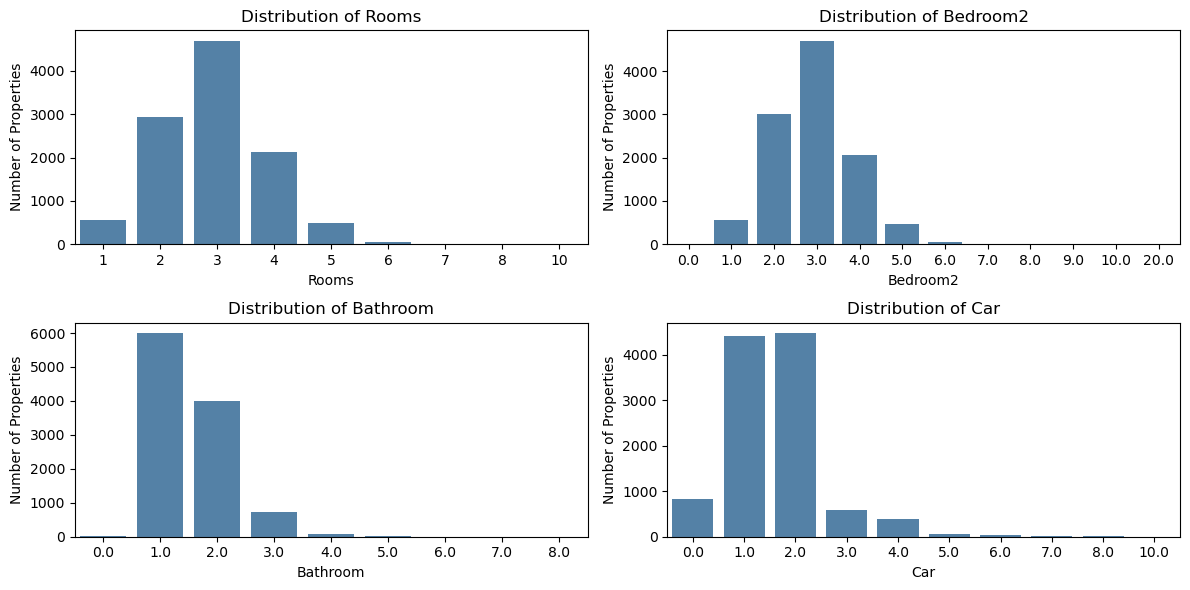

In [21]:
count_features = ["Rooms", "Bedroom2", "Bathroom", "Car"]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

for feature, ax in zip(count_features, axes):
    sns.countplot(
        data=train_df,
        x=feature,
        ax=ax,
        color="steelblue"
    )

    ax.set_title(f"Distribution of {feature}")
    ax.set_ylabel("Number of Properties")

plt.tight_layout()

plt.savefig(
    project_root / "results" / "figures" / "structural_count_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
rooms_summary = (
    train_df["Rooms"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

rooms_summary["Percentage"] = (
    rooms_summary["Count"]
    / train_df["Rooms"].notna().sum()
    * 100
).round(2)

rooms_summary

,Count,Percentage
Rooms,,
1,550,5.06
2,2928,26.95
3,4700,43.26
4,2131,19.62
5,489,4.50
6,50,0.46
7,8,0.07
8,7,0.06
10,1,0.01


In [23]:
maximum_rooms = train_df["Rooms"].max()

print("Maximum Rooms:", maximum_rooms)

train_df.loc[
    train_df["Rooms"] == maximum_rooms,
    [
        "Suburb", "Address", "Rooms", "Bedroom2",
        "Bathroom", "Car", "Type", "Price",
        "Landsize", "BuildingArea", "YearBuilt"
    ]
]

Maximum Rooms: 10


,Suburb,Address,Rooms,Bedroom2,Bathroom,Car,Type,Price,Landsize,BuildingArea,YearBuilt
11304,Bundoora,5 Ball Ct,10,10.0,3.0,2.0,h,900000.0,313.0,NaN,2006.0


### Observation

The distribution of `Rooms` is strongly concentrated around typical residential properties. Three-room properties are the most common at 43.26%, while 89.83% of the training properties contain between two and four rooms. Properties with six or more rooms represent only approximately 0.60% of the training data.

The maximum value of 10 rooms occurs in one house. Its alternative bedroom count is also 10, while its bathrooms, car spaces, land size, construction year, and price are plausible. Although the building area is unavailable and the observation is rare, there is insufficient evidence to classify it as an error. The record will be retained and its influence will be assessed during model diagnostics. The similarity between `Rooms` and `Bedroom2` will also be investigated later for possible multicollinearity.

### 16.2 Distribution of Bedroom Count

The distribution of `Bedroom2` is examined to identify common bedroom counts, zero values, and unusually large observations. These values are inspected before making any preprocessing decision.

In [24]:
bedroom2_summary = (
    train_df["Bedroom2"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

bedroom2_summary["Percentage"] = (
    bedroom2_summary["Count"]
    / train_df["Bedroom2"].notna().sum()
    * 100
).round(2)

print(
    "Missing Bedroom2 values:",
    train_df["Bedroom2"].isna().sum()
)

bedroom2_summary

Missing Bedroom2 values: 0


,Count,Percentage
Bedroom2,,
0.0,12,0.11
1.0,557,5.13
2.0,3001,27.62
3.0,4710,43.35
4.0,2060,18.96
5.0,459,4.22
6.0,50,0.46
7.0,6,0.06
8.0,5,0.05


#### 16.2.1 Inspect Zero-Bedroom Properties

Properties with a recorded `Bedroom2` value of zero are inspected using their property type, room count, bathrooms, size, and price. This helps determine whether zero is a plausible value or a possible data-quality issue.

In [66]:
zero_bedroom_properties = train_df.loc[
    train_df["Bedroom2"] == 0,
    [
        "Suburb", "Address", "Type",
        "Rooms", "Bedroom2", "Bathroom",
        "Car", "Price", "Landsize",
        "BuildingArea", "YearBuilt"
    ]
].sort_values(["Type", "Rooms"])

print(
    "Zero-bedroom properties:",
    len(zero_bedroom_properties)
)

zero_bedroom_properties

Zero-bedroom properties: 12


,Suburb,Address,Type,Rooms,Bedroom2,Bathroom,Car,Price,Landsize,BuildingArea,YearBuilt
9917,Hawthorn,1/30 Lisson Gr,h,2,0.0,0.0,0.0,1480000.0,241.0,NaN,NaN
913,Bentleigh East,579 Warrigal Rd,h,3,0.0,0.0,0.0,700000.0,456.0,NaN,NaN
827,Bentleigh East,7 Wallace St,h,3,0.0,1.0,2.0,1355000.0,818.0,NaN,NaN
7494,Balwyn North,215 Doncaster Rd,h,3,0.0,0.0,0.0,1670000.0,818.0,NaN,NaN
6893,Fawkner,4 Lord St,h,3,0.0,1.0,1.0,585000.0,605.0,103.0,1960.0
7385,South Kingsville,55 Saltley St,h,3,0.0,1.0,1.0,1030000.0,224.0,NaN,NaN
8998,Airport West,8 Kittyhawk St,h,4,0.0,3.0,2.0,1026000.0,534.0,NaN,NaN
8301,Reservoir,96b Cheddar Rd,h,4,0.0,1.0,2.0,678500.0,606.0,NaN,NaN
3360,Ivanhoe,20 Locksley Rd,h,4,0.0,2.0,2.0,2400000.0,1252.0,201.0,1920.0
804,Bentleigh East,17a Edinburgh St,t,3,0.0,2.0,2.0,830000.0,292.0,141.0,2012.0


##### Observation

All 12 properties with `Bedroom2 = 0` contain between two and four recorded rooms. These observations include nine houses, one townhouse, and two units, all with valid positive sale prices. Several rows also contain zero values in other structural fields or missing building information, indicating possible incomplete property records rather than genuine zero-bedroom homes.

Therefore, zero values in `Bedroom2` will be treated as missing information during preprocessing. The complete property rows will be retained, and the missing bedroom values will be imputed using a statistic learned only from the training data. `Rooms` will not be copied directly into `Bedroom2` because the two variables are related but are not guaranteed to have identical definitions.

#### 16.2.2 Inspect the Maximum Bedroom Count

The property with the maximum `Bedroom2` value is inspected using its room count, structural characteristics, property type, location, and price. This helps determine whether the extreme bedroom count is plausible or a possible data-entry error.

In [25]:
maximum_bedrooms = train_df["Bedroom2"].max()

print(
    "Maximum Bedroom2:",
    maximum_bedrooms
)

train_df.loc[
    train_df["Bedroom2"] == maximum_bedrooms,
    [
        "Suburb", "Address", "Type",
        "Rooms", "Bedroom2", "Bathroom",
        "Car", "Price", "Distance",
        "Landsize", "BuildingArea",
        "YearBuilt", "Regionname"
    ]
]

Maximum Bedroom2: 20.0


,Suburb,Address,Type,Rooms,Bedroom2,Bathroom,Car,Price,Distance,Landsize,BuildingArea,YearBuilt,Regionname
7404,Caulfield East,5 Grange Rd,h,3,20.0,1.0,2.0,1650000.0,9.3,875.0,NaN,NaN,Southern Metropolitan


##### Observation

The maximum `Bedroom2` value of 20 belongs to a three-room house with one bathroom and two car spaces. Although the property has a relatively large land size and a valid sale price, its remaining structural information does not support a literal count of 20 bedrooms. Building area and construction year are also unavailable, preventing complete verification.

The value of 20 is therefore considered a highly implausible bedroom record and will be treated as missing during preprocessing. The property row will be retained, and the invalid bedroom value will be imputed using information learned only from the training data. It will not be replaced directly with the `Rooms` value because the two variables are related but not guaranteed to have identical definitions.

### 16.3 Distribution of Bathrooms

The distribution of `Bathroom` is examined to identify common bathroom counts, zero values, and unusually large observations before defining any preprocessing treatment.

In [26]:
bathroom_summary = (
    train_df["Bathroom"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

bathroom_summary["Percentage"] = (
    bathroom_summary["Count"]
    / train_df["Bathroom"].notna().sum()
    * 100
).round(2)

print(
    "Missing Bathroom values:",
    train_df["Bathroom"].isna().sum()
)

bathroom_summary

Missing Bathroom values: 0


,Count,Percentage
Bathroom,,
0.0,25,0.23
1.0,6000,55.23
2.0,3994,36.76
3.0,731,6.73
4.0,87,0.80
5.0,20,0.18
6.0,4,0.04
7.0,1,0.01
8.0,2,0.02


#### 16.3.1 Inspect Zero-Bathroom Properties

Properties with a recorded `Bathroom` value of zero are inspected using their property type, room counts, size, and price. This helps determine whether zero is a plausible value or represents unavailable structural information.

In [27]:
zero_bathroom_properties = train_df.loc[
    train_df["Bathroom"] == 0,
    [
        "Suburb", "Address", "Type",
        "Rooms", "Bedroom2", "Bathroom",
        "Car", "Price", "Landsize",
        "BuildingArea", "YearBuilt"
    ]
].sort_values(["Type", "Rooms"])

print(
    "Zero-bathroom properties:",
    len(zero_bathroom_properties)
)

zero_bathroom_properties

Zero-bathroom properties: 25


,Suburb,Address,Type,Rooms,Bedroom2,Bathroom,Car,Price,Landsize,BuildingArea,YearBuilt
3787,Malvern,42 Cressy St,h,2,2.0,0.0,0.0,780000.0,0.0,NaN,NaN
6671,Yarraville,1a Kingston St,h,2,2.0,0.0,0.0,610000.0,94.0,NaN,NaN
584,Balwyn,5 Shrimpton Ct,h,2,2.0,0.0,0.0,1010000.0,1611.0,NaN,NaN
9917,Hawthorn,1/30 Lisson Gr,h,2,0.0,0.0,0.0,1480000.0,241.0,NaN,NaN
10795,Preston,24 Mitchell St,h,3,3.0,0.0,0.0,1150000.0,502.0,NaN,NaN
139,Alphington,6 Naroon Rd,h,3,3.0,0.0,0.0,1485000.0,597.0,NaN,NaN
913,Bentleigh East,579 Warrigal Rd,h,3,0.0,0.0,0.0,700000.0,456.0,NaN,NaN
1063,Brighton,17 New St,h,3,3.0,0.0,0.0,1900000.0,0.0,NaN,NaN
7494,Balwyn North,215 Doncaster Rd,h,3,0.0,0.0,0.0,1670000.0,818.0,NaN,NaN
4880,Preston,19 Malpas St,h,4,3.0,0.0,0.0,1004000.0,650.0,NaN,NaN


##### Observation

The 25 properties with `Bathroom = 0` contain positive room counts and valid sale prices and include houses, townhouses, and units. All 25 records have missing `BuildingArea`, 24 have missing `YearBuilt`, and 24 also record zero car spaces. This shared pattern indicates incomplete structural information rather than genuine residential properties without bathrooms.

Therefore, zero values in `Bathroom` will be treated as missing during preprocessing. The complete property rows will be retained, and the missing bathroom values will be imputed using a statistic learned only from the training data. Zero values in `Car` will be investigated separately because the absence of dedicated parking can be valid.

#### 16.3.2 Inspect Properties with the Highest Bathroom Counts

Properties containing seven or more bathrooms are inspected using their room counts, size, type, location, and price. This helps determine whether the rare bathroom values are plausible luxury-property characteristics or possible data errors.

In [67]:
high_bathroom_properties = train_df.loc[
    train_df["Bathroom"] >= 7,
    [
        "Suburb", "Address", "Type",
        "Rooms", "Bedroom2", "Bathroom",
        "Car", "Price", "Distance",
        "Landsize", "BuildingArea",
        "YearBuilt", "Regionname"
    ]
].sort_values("Bathroom", ascending=False)

print(
    "Properties with 7 or more bathrooms:",
    len(high_bathroom_properties)
)

high_bathroom_properties

Properties with 7 or more bathrooms: 3


,Suburb,Address,Type,Rooms,Bedroom2,Bathroom,Car,Price,Distance,Landsize,BuildingArea,YearBuilt,Regionname
10611,Camberwell,1088 Toorak Rd,h,8,8.0,8.0,4.0,2200000.0,7.7,650.0,NaN,NaN,Southern Metropolitan
4980,Preston,421 Murray Rd,h,4,9.0,8.0,7.0,760000.0,8.8,1254.0,280.0,1928.0,Northern Metropolitan
580,Balwyn,29 Sevenoaks St,h,5,5.0,7.0,6.0,3900000.0,9.7,0.0,NaN,NaN,Southern Metropolitan


##### Observation

The three properties containing seven or more bathrooms have structural characteristics that provide reasonable support for their high bathroom counts. One property contains eight rooms, eight bedrooms, and eight bathrooms, while another contains nine recorded bedrooms, eight bathrooms, seven car spaces, and a large land area. The seven-bathroom property also has five bedrooms, six car spaces, and a high sale price.

Although some fields show inconsistencies or missing information, there is insufficient evidence to classify the high bathroom counts themselves as errors. Values from one to eight bathrooms will therefore be retained. Only zero bathroom values will be treated as missing during preprocessing. The influence of rare high bathroom counts will be assessed later through model and residual diagnostics.

### 16.4 Distribution of Car Spaces

The distribution of `Car` is examined to identify missing values, properties without recorded parking, common parking capacities, and unusually large values before defining a preprocessing strategy.

In [28]:
car_summary = (
    train_df["Car"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

car_summary["Percentage"] = (
    car_summary["Count"]
    / train_df["Car"].notna().sum()
    * 100
).round(2)

print(
    "Missing Car values:",
    train_df["Car"].isna().sum()
)

print(
    "Available Car values:",
    train_df["Car"].notna().sum()
)

car_summary

Missing Car values: 50
Available Car values: 10814


,Count,Percentage
Car,,
0.0,828,7.66
1.0,4407,40.75
2.0,4483,41.46
3.0,583,5.39
4.0,397,3.67
5.0,53,0.49
6.0,48,0.44
7.0,7,0.06
8.0,5,0.05


#### 16.4.1 Investigate Missing Car Values

Properties with missing `Car` values are examined by property type and by their overlap with other missing fields. This helps determine whether parking information is independently missing or part of a broader data-collection pattern.

In [29]:
missing_car_properties = train_df.loc[
    train_df["Car"].isna()
].copy()

print(
    "Properties with missing Car:",
    len(missing_car_properties)
)

print("\nProperty type counts:")
print(
    missing_car_properties["Type"]
    .value_counts()
)

print("\nOther missing values within these rows:")
print(
    missing_car_properties[
        ["BuildingArea", "YearBuilt", "CouncilArea"]
    ]
    .isna()
    .sum()
)

Properties with missing Car: 50

Property type counts:
Type
h    48
u     2
Name: count, dtype: int64

Other missing values within these rows:
BuildingArea    24
YearBuilt       23
CouncilArea     50
dtype: int64


##### Observation

Among the 50 properties with missing `Car` values, 48 are houses and two are units. All 50 records also have missing `CouncilArea`, while 24 have missing `BuildingArea` and 23 have missing `YearBuilt`. This strong overlap suggests that missing parking information may be associated with a broader data-collection pattern rather than occurring independently.

These property records will be retained. Missing `Car` values will be imputed using the median learned within the training pipeline, and a missing-value indicator will preserve information about which values were originally unavailable. Recorded zero car spaces will be investigated separately because the absence of dedicated parking can be genuine.

#### 16.4.2 Analyze Zero Car Spaces by Property Type

The frequency of zero recorded car spaces is compared across houses, townhouses, and units. This helps determine whether zero is a plausible property characteristic or a possible missing-data code.

In [30]:
zero_car_by_type = (
    train_df
    .groupby("Type")["Car"]
    .agg(
        Available_Count="count",
        Zero_Car_Count=lambda values: (values == 0).sum()
    )
)

zero_car_by_type["Zero_Car_Percentage"] = (
    zero_car_by_type["Zero_Car_Count"]
    / zero_car_by_type["Available_Count"]
    * 100
).round(2)

zero_car_by_type

,Available_Count,Zero_Car_Count,Zero_Car_Percentage
Type,,,
h,7484,682,9.11
t,903,10,1.11
u,2427,136,5.60


#### 16.4.3 Investigate Data-Quality Overlap Within Zero-Car Properties

Zero-car properties are examined for zero bathroom and bedroom counts and for missing building, construction-year, and council information. This helps separate plausible no-parking properties from records that may contain incomplete structural information.

In [31]:
zero_car_properties = train_df.loc[
    train_df["Car"] == 0
].copy()

zero_car_overlap = pd.DataFrame(
    {
        "Count": [
            (zero_car_properties["Bathroom"] == 0).sum(),
            (zero_car_properties["Bedroom2"] == 0).sum(),
            zero_car_properties["BuildingArea"].isna().sum(),
            zero_car_properties["YearBuilt"].isna().sum(),
            zero_car_properties["CouncilArea"].isna().sum()
        ]
    },
    index=[
        "Bathroom also zero",
        "Bedroom2 also zero",
        "BuildingArea missing",
        "YearBuilt missing",
        "CouncilArea missing"
    ]
)

zero_car_overlap["Percentage"] = (
    zero_car_overlap["Count"]
    / len(zero_car_properties)
    * 100
).round(2)

print(
    "Zero-car properties:",
    len(zero_car_properties)
)

zero_car_overlap

Zero-car properties: 828


,Count,Percentage
Bathroom also zero,24,2.90
Bedroom2 also zero,4,0.48
BuildingArea missing,439,53.02
YearBuilt missing,374,45.17
CouncilArea missing,41,4.95


##### Observation

Among the 828 properties with zero recorded car spaces, 24 also have zero bathrooms and four have zero bedroom counts. Missing `BuildingArea` and `YearBuilt` are moderately more common in the zero-car group than in the full training data. However, 804 zero-car properties have positive bathroom counts, and missing `CouncilArea` is less common in this group than in the complete training dataset.

This pattern does not support treating all zero car-space values as missing. Recorded `Car = 0` values will therefore be retained as plausible properties without dedicated parking. Actual missing `Car` values will remain a separate case and will be imputed within the training pipeline. A zero-car indicator may be evaluated through training-data cross-validation.

#### 16.4.4 Inspect the Maximum Car-Space Values

Properties with the maximum recorded number of car spaces are inspected using their structural characteristics, land size, location, and price. This helps determine whether the rare parking values are plausible or possible data errors.

In [32]:
maximum_car_spaces = train_df["Car"].max()

print(
    "Maximum Car spaces:",
    maximum_car_spaces
)

maximum_car_properties = train_df.loc[
    train_df["Car"] == maximum_car_spaces,
    [
        "Suburb", "Address", "Type",
        "Rooms", "Bedroom2", "Bathroom",
        "Car", "Price", "Distance",
        "Landsize", "BuildingArea",
        "YearBuilt", "Regionname"
    ]
]

print(
    "Properties with maximum Car spaces:",
    len(maximum_car_properties)
)

maximum_car_properties

Maximum Car spaces: 10.0
Properties with maximum Car spaces: 3


,Suburb,Address,Type,Rooms,Bedroom2,Bathroom,Car,Price,Distance,Landsize,BuildingArea,YearBuilt,Regionname
13527,Reservoir,1 Don St,h,4,4.0,2.0,10.0,1112000.0,12.0,1002.0,170.0,1985.0,Northern Metropolitan
9423,Bayswater,95 Orange Gr,h,4,4.0,1.0,10.0,925000.0,23.2,993.0,128.0,1966.0,Eastern Metropolitan
11642,Dandenong,1462 Heatherton Rd,h,3,3.0,2.0,10.0,880000.0,24.7,734.0,NaN,NaN,South-Eastern Metropolitan


##### Observation

The three properties with the maximum recorded value of 10 car spaces are all houses located on relatively large land parcels ranging from 734 to 1,002 square metres. Their room counts, property types, locations, and sale prices are plausible. Because car spaces may include driveways, carports, and open on-site parking rather than only enclosed garages, the value of 10 is physically possible.

There is insufficient evidence to classify these maximum values as data errors. Recorded car-space values from zero to ten will therefore be retained. Only actual missing `Car` values will be imputed within the training pipeline, accompanied by a missing-value indicator. The influence of rare high values will be assessed through scaling, regularization, and model diagnostics.

## 17. Continuous Numerical Features

Continuous numerical features are examined for their ranges, distributions, skewness, unusual values, and possible relationships with house prices.

### 17.1 Summary of `Distance`

`Distance` represents the property's distance from Melbourne CBD in kilometres. Its descriptive statistics, missing values, zero values, and skewness are examined before plotting its distribution.

In [33]:
distance_summary = train_df["Distance"].describe()

display(
    distance_summary.to_frame(name="Distance")
    .style.format("{:,.2f}")
)

print("Missing Distance values:", train_df["Distance"].isna().sum())
print("Zero Distance values:", (train_df["Distance"] == 0).sum())
print(f"Distance skewness: {train_df['Distance'].skew():.4f}")

,Distance
count,"10,864.00"
mean,10.10
std,5.89
min,0.00
25%,6.10
50%,9.20
75%,13.00
max,48.10


Missing Distance values: 0
Zero Distance values: 5
Distance skewness: 1.6846


#### Observation

`Distance` contains no missing values in the training data. Its median is 9.20 km, while the middle 50% of properties are located between 6.10 km and 13.00 km from the CBD. The mean distance of 10.10 km is higher than the median, and the skewness of 1.6846 confirms a positively skewed distribution with a relatively long right tail extending to 48.10 km.

Only five properties, approximately 0.05% of the training data, have a recorded distance of zero. These values will not be treated as missing or erroneous without inspecting their property and location details. No transformation or removal decision will be made from feature skewness alone; the relationship with `Price` and model-validation results will also be considered.

### 17.2 Inspect Properties with Zero Distance

Properties with a recorded distance of zero are inspected using their suburb, postcode, geographical coordinates, property type, and region. This helps determine whether zero represents a valid central location or a possible data-quality problem.

In [34]:
zero_distance_columns = [
    "Suburb",
    "Address",
    "Postcode",
    "Regionname",
    "CouncilArea",
    "Type",
    "Rooms",
    "Price",
    "Distance",
    "Lattitude",
    "Longtitude"
]

zero_distance_properties = train_df.loc[
    train_df["Distance"] == 0,
    zero_distance_columns
].sort_values("Price", ascending=False)

print("Zero-distance properties:", len(zero_distance_properties))

display(zero_distance_properties)

Zero-distance properties: 5


,Suburb,Address,Postcode,Regionname,CouncilArea,Type,Rooms,Price,Distance,Lattitude,Longtitude
10739,Melbourne,61/299 Queen St,3000.0,Northern Metropolitan,Melbourne,u,2,1075000.0,0.0,-37.81141,144.95879
10393,Melbourne,1814/250 Elizabeth St,3000.0,Northern Metropolitan,Melbourne,u,2,720000.0,0.0,-37.81267,144.96273
12073,Melbourne,709/87 Franklin St,3000.0,Northern Metropolitan,Melbourne,u,2,565000.0,0.0,-37.80802,144.96168
12074,Melbourne,713/118 Russell St,3000.0,Northern Metropolitan,Melbourne,u,2,540000.0,0.0,-37.81351,144.96908
11428,Melbourne,806/22 Coromandel Pl,3000.0,Northern Metropolitan,Melbourne,u,2,387000.0,0.0,-37.81301,144.96924


#### Observation

All five zero-distance properties are located in the `Melbourne` suburb, have postcode `3000`, belong to the Melbourne council area, and are classified as two-room units. Their apartment-style addresses and closely grouped geographical coordinates provide consistent evidence that they are located within or very close to the CBD reference area.

The zero values therefore appear to represent valid central locations rather than missing or erroneous measurements. These values will be retained without imputation or replacement. The complete `Distance` feature will remain available for later relationship analysis and model evaluation.

### 17.3 Visualize the Distribution of `Distance`

A histogram with a density curve and a box plot are used together to examine the shape, concentration, spread, and unusually large values of the `Distance` feature.

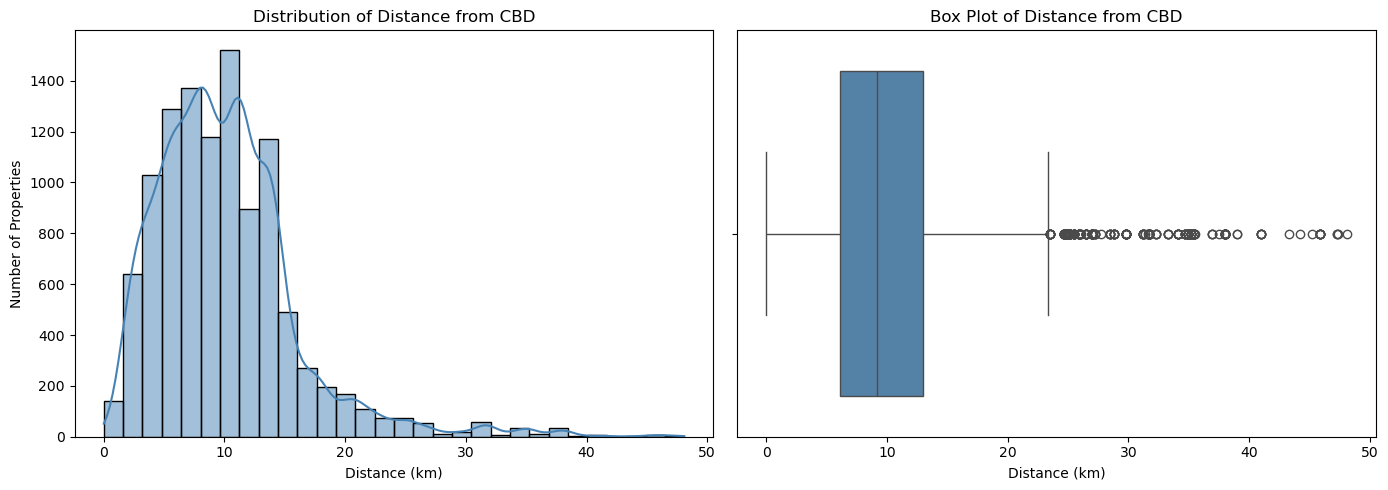

Saved: C:\Users\mamona\Desktop\house-price-linear-models\results\figures\distance_distribution_and_boxplot.png


In [35]:
figures_path = project_root / "results" / "figures"
figures_path.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=train_df,
    x="Distance",
    bins=30,
    kde=True,
    color="steelblue",
    edgecolor="black",
    ax=axes[0]
)

axes[0].set_title("Distribution of Distance from CBD")
axes[0].set_xlabel("Distance (km)")
axes[0].set_ylabel("Number of Properties")

sns.boxplot(
    data=train_df,
    x="Distance",
    color="steelblue",
    ax=axes[1]
)

axes[1].set_title("Box Plot of Distance from CBD")
axes[1].set_xlabel("Distance (km)")

plt.tight_layout()

distance_figure_path = (
    figures_path / "distance_distribution_and_boxplot.png"
)

plt.savefig(
    distance_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", distance_figure_path)

#### Observation

The histogram confirms that `Distance` is positively skewed, with most properties concentrated approximately between 4 km and 15 km from the CBD and a long right tail extending to 48.10 km. The box plot shows a median of 9.20 km and an interquartile range from 6.10 km to 13.00 km.

Using the IQR rule, distances above approximately 23.35 km are identified as potential high-distance outliers. However, these observations may represent genuine properties located in outer suburbs rather than data errors. Therefore, no distance values will be removed or transformed solely on the basis of this plot. The potential outliers and the relationship between `Distance` and `Price` will be investigated before making a preprocessing decision.

### 17.4 Quantify Potential `Distance` Outliers

The IQR rule is applied to quantify properties with unusually low or high distances from the CBD. These values are labelled as potential outliers for investigation and are not automatically treated as data errors.

In [36]:
distance_q1 = train_df["Distance"].quantile(0.25)
distance_q3 = train_df["Distance"].quantile(0.75)

distance_iqr = distance_q3 - distance_q1

distance_lower_boundary = distance_q1 - 1.5 * distance_iqr
distance_upper_boundary = distance_q3 + 1.5 * distance_iqr

lower_distance_outliers = (
    train_df["Distance"] < distance_lower_boundary
).sum()

upper_distance_outliers = (
    train_df["Distance"] > distance_upper_boundary
).sum()

total_distance_outliers = (
    lower_distance_outliers + upper_distance_outliers
)

distance_outlier_percentage = (
    total_distance_outliers / len(train_df) * 100
)

print(f"Q1: {distance_q1:.2f} km")
print(f"Q3: {distance_q3:.2f} km")
print(f"IQR: {distance_iqr:.2f} km")
print(f"Lower boundary: {distance_lower_boundary:.2f} km")
print(f"Upper boundary: {distance_upper_boundary:.2f} km")
print("Lower-distance potential outliers:", lower_distance_outliers)
print("Upper-distance potential outliers:", upper_distance_outliers)
print("Total potential outliers:", total_distance_outliers)
print(f"Potential outlier percentage: {distance_outlier_percentage:.2f}%")

Q1: 6.10 km
Q3: 13.00 km
IQR: 6.90 km
Lower boundary: -4.25 km
Upper boundary: 23.35 km
Lower-distance potential outliers: 0
Upper-distance potential outliers: 335
Total potential outliers: 335
Potential outlier percentage: 3.08%


#### Observation

The IQR method produced a lower boundary of -4.25 km and an upper boundary of 23.35 km. Because physical distance cannot be negative and the observed minimum is zero, no lower-distance potential outliers were identified.

A total of 335 properties, representing 3.08% of the training data, lie above the upper boundary. These observations are statistically unusual relative to the majority of properties, but they may represent valid outer-suburb locations rather than data errors. Removing them without investigation could reduce geographical coverage and bias the model toward properties closer to the CBD. Therefore, all high-distance observations will be retained while their location details are investigated.

### 17.5 Inspect the Farthest Properties

The ten properties with the largest recorded distances are inspected using their suburb, postcode, council area, region, coordinates, and property characteristics. This row-level inspection helps distinguish valid outer-suburb properties from possible recording errors.

In [37]:
farthest_columns = [
    "Suburb",
    "Address",
    "Postcode",
    "CouncilArea",
    "Regionname",
    "Distance",
    "Type",
    "Rooms",
    "Price",
    "Lattitude",
    "Longtitude"
]

farthest_properties = (
    train_df.loc[
        train_df["Distance"] > distance_upper_boundary,
        farthest_columns
    ]
    .sort_values(
        by=["Distance", "Price"],
        ascending=[False, False]
    )
    .head(10)
)

print("Properties above the upper boundary:", upper_distance_outliers)
print(f"Maximum recorded distance: {train_df['Distance'].max():.2f} km")

display(farthest_properties)

Properties above the upper boundary: 335
Maximum recorded distance: 48.10 km


,Suburb,Address,Postcode,CouncilArea,Regionname,Distance,Type,Rooms,Price,Lattitude,Longtitude
13245,New Gisborne,71 Hamilton Rd,3438.0,NaN,Northern Victoria,48.1,h,5,1355000.0,-37.45392,144.58864
10033,Riddells Creek,53 Bluegum Cct,3431.0,Macedon Ranges,Northern Victoria,47.4,h,4,817000.0,-37.45709,144.68999
11763,Pakenham,1 Loxton Wy,3810.0,Cardinia,Eastern Victoria,47.3,h,4,643500.0,-38.07583,145.43698
11470,Pakenham,4 Toorang Ct,3810.0,Cardinia,Eastern Victoria,47.3,h,4,435000.0,-38.08699,145.48273
11371,Gisborne,21 Braeside Rd,3437.0,Macedon Ranges,Northern Victoria,45.9,h,4,807000.0,-37.50929,144.56444
12504,Gisborne,204 Panorama Dr,3437.0,NaN,Northern Victoria,45.9,h,4,780000.0,-37.49674,144.62618
12503,Gisborne,15 Morilla Ct,3437.0,NaN,Northern Victoria,45.9,h,3,690000.0,-37.50624,144.58134
12728,Gisborne,7 Wyralla Cr,3437.0,NaN,Northern Victoria,45.9,h,6,650000.0,-37.50733,144.58666
9549,Gisborne,60 Hamilton St,3437.0,Macedon Ranges,Northern Victoria,45.9,h,3,540000.0,-37.48701,144.58567
10938,Bullengarook,31 Carrolls La,3437.0,Macedon Ranges,Northern Victoria,45.9,h,3,535000.0,-37.50087,144.48571


#### Observation

The farthest properties show coherent geographical patterns rather than random or impossible values. Properties from the same outer suburbs have identical or similar recorded distances, while their postcodes, regions, and geographical coordinates are internally consistent. For example, the Pakenham properties share a distance of 47.3 km, and several Gisborne-area properties share a distance of 45.9 km.

The inspected records are houses with plausible room counts, sale prices, and individual addresses. Missing `CouncilArea` values in some rows represent a separate missing-data issue and do not invalidate the available distance and location information.

These findings support treating the high-distance observations as valid outer-location properties. Therefore, all 335 potential high-distance outliers, including the maximum distance of 48.10 km, will be retained without removal or clipping. Any transformation or non-linear treatment of `Distance` will be evaluated later using its relationship with `Price` and training cross-validation.

### 17.6 Examine the Relationship Between `Distance` and `Price`

A scatter plot is used to explore how property prices vary with distance from the CBD in the training data. This helps identify broad trends, price variability, and possible non-linear patterns.

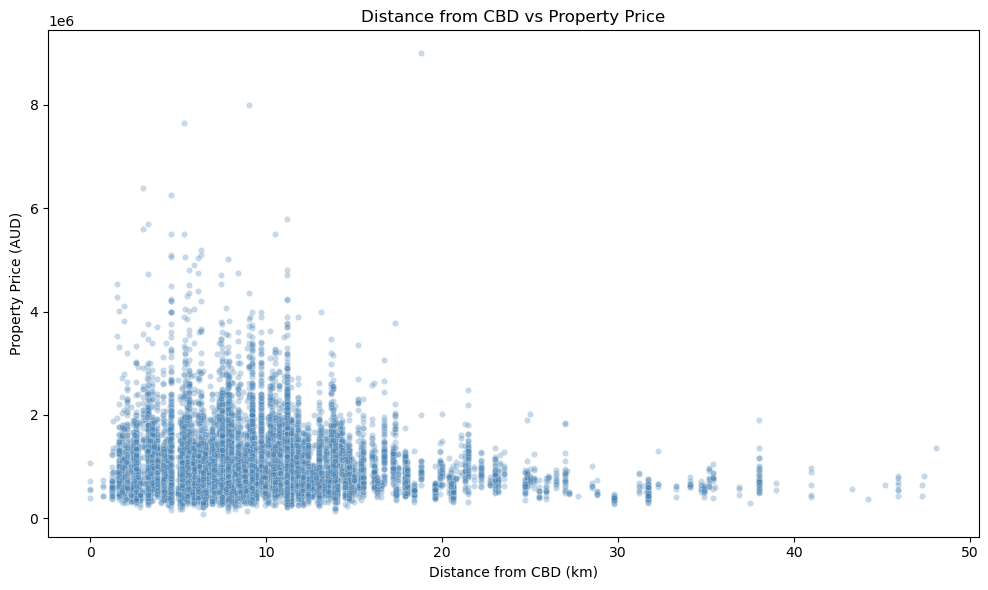

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=train_df,
    x="Distance",
    y="Price",
    alpha=0.3,
    s=20,
    color="steelblue",
    ax=ax
)

ax.set_title("Distance from CBD vs Property Price")
ax.set_xlabel("Distance from CBD (km)")
ax.set_ylabel("Property Price (AUD)")

plt.tight_layout()

plt.savefig(
    figures_path / "distance_vs_price_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation

The scatter plot suggests that properties farther from the CBD generally have lower prices, although the relationship is not a clear straight-line pattern. Prices vary considerably at similar distances, indicating that `Distance` alone cannot explain property prices.

The price spread appears wider at nearer distances and narrower at larger distances, where fewer observations are available. Several expensive properties remain visible as exceptions to the broad pattern.

Vertical bands indicate repeated recorded distance values, which may reflect rounded or location-level measurements. These patterns do not justify removing or transforming observations by themselves. Further analysis will examine grouped price trends and differences across property types using training data only.

### 17.7 Summarize Property Prices by Distance Band

Training properties are grouped into distance bands to compare property counts and median prices across locations. Counts provide context for interpreting groups with fewer observations.

These bands are used for exploratory analysis only; the original `Distance` feature remains unchanged.

In [39]:
distance_analysis = train_df[["Distance", "Price"]].copy()

distance_bins = [0, 5, 10, 15, 20, 30, float("inf")]
distance_labels = [
    "0–5", ">5–10", ">10–15",
    ">15–20", ">20–30", ">30"
]

distance_analysis["Distance_Band"] = pd.cut(
    distance_analysis["Distance"],
    bins=distance_bins,
    labels=distance_labels,
    include_lowest=True,
    right=True
)

distance_price_summary = (
    distance_analysis
    .groupby("Distance_Band", observed=False)
    .agg(
        Property_Count=("Price", "size"),
        Median_Price=("Price", "median")
    )
)

display(distance_price_summary)

tables_path = project_root / "results" / "tables"
tables_path.mkdir(parents=True, exist_ok=True)

distance_price_summary.to_csv(
    tables_path / "distance_band_price_summary.csv"
)

,Property_Count,Median_Price
Distance_Band,,
0–5,1829,1000000.0
>5–10,4075,967500.0
>10–15,3656,875000.0
>15–20,709,815000.0
>20–30,424,740000.0
>30,171,605000.0


#### Observation

Median property prices decrease across successive distance bands, from AUD 1,000,000 within 0–5 km of the CBD to AUD 605,000 beyond 30 km. The farthest band's median is 39.5% lower than that of the nearest band.

Group sizes differ considerably, with 4,075 properties in the >5–10 km band and only 171 beyond 30 km. Estimates from smaller groups should therefore be interpreted cautiously.

This grouped pattern supports a negative association between distance and price, but it does not establish a linear or causal relationship. Differences in property type and other characteristics may contribute to the observed trend. The next analysis will compare median prices within property types across distance bands.

### 17.8 Compare Distance–Price Patterns Within Property Types

Property counts and median prices are calculated for each combination of distance band and property type. This helps assess whether the overall distance–price pattern also appears within individual property types.

This comparison accounts for property type only; other differences, such as property size and suburb, remain.

In [40]:
distance_analysis["Type"] = train_df["Type"]

distance_type_summary = (
    distance_analysis
    .groupby(["Distance_Band", "Type"], observed=True)
    .agg(
        Property_Count=("Price", "size"),
        Median_Price=("Price", "median")
    )
    .reset_index()
)

display(distance_type_summary)

distance_type_summary.to_csv(
    tables_path / "distance_band_price_by_type.csv",
    index=False
)

,Distance_Band,Type,Property_Count,Median_Price
0,0–5,h,923,1340000.0
1,0–5,t,124,1015000.0
2,0–5,u,782,580000.0
3,>5–10,h,2759,1215000.0
4,>5–10,t,340,820000.0
5,>5–10,u,976,520000.0
6,>10–15,h,2711,980500.0
7,>10–15,t,371,840000.0
8,>10–15,u,574,585500.0
9,>15–20,h,599,853000.0


###  Distance Preprocessing Decision

`Distance` will be retained as a numerical predictor. All 10,864 training records have available distance values, so no missing-distance correction is required in the current training data.

Weak overall correlations with price do not justify removing the feature. Median prices decline across distance bands, particularly within houses, while patterns differ for townhouses and units.

Large distances will not be removed or capped solely because they exceed an IQR threshold. Such thresholds identify unusual observations rather than prove recording errors.

The original numerical values will be used for the initial models. Distance bands remain exploratory summaries. Scaling will be fitted within each training or cross-validation fold and then applied to the corresponding validation or test data.

A distance-by-property-type interaction may be evaluated later using training-only cross-validation.

## 18. Land Size Distribution and Extreme Values

### 18.1 Summarize Positive Land Sizes

Zero land-size records were investigated in Section 15. This step examines positive `Landsize` values in the training data, including upper percentiles, to understand their spread and identify values requiring further inspection.

Zero and missing values are excluded only from this descriptive summary. The original training data remains unchanged.

In [43]:
# Select positive land sizes for this summary
positive_landsize = train_df.loc[
    train_df["Landsize"] > 0, "Landsize"
]

# Inspect the distribution, including upper percentiles
positive_landsize.describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

count     9296.00
mean       612.57
std       1474.14
min          1.00
25%        267.00
50%        532.00
75%        675.00
90%        836.00
95%       1039.25
99%       3512.20
max      75100.00
Name: Landsize, dtype: float64

#### Observation

The training data contains 9,296 positive `Landsize` values. The median is 532 m², with the central 50% ranging from 267 m² to 675 m².

The mean of 612.57 m² exceeds the median, while the upper percentiles and maximum suggest a long right tail. The 95th and 99th percentiles are 1,039.25 m² and 3,512.20 m², respectively, whereas the maximum reaches 75,100 m².

The maximum requires row-level investigation to distinguish a plausible large property from a possible recording issue. The minimum positive value of 1 m² also warrants inspection.

No values are removed, capped, or transformed at this stage. Zero and missing values were excluded only from this descriptive summary.

### 18.2 Visualize Positive Land Sizes

A histogram displays the full distribution of positive land sizes on the original scale. A box plot with a logarithmic x-axis helps reveal the central spread and extreme values across the wide range.

The logarithmic axis is used only for visualization. The original training data remains unchanged.

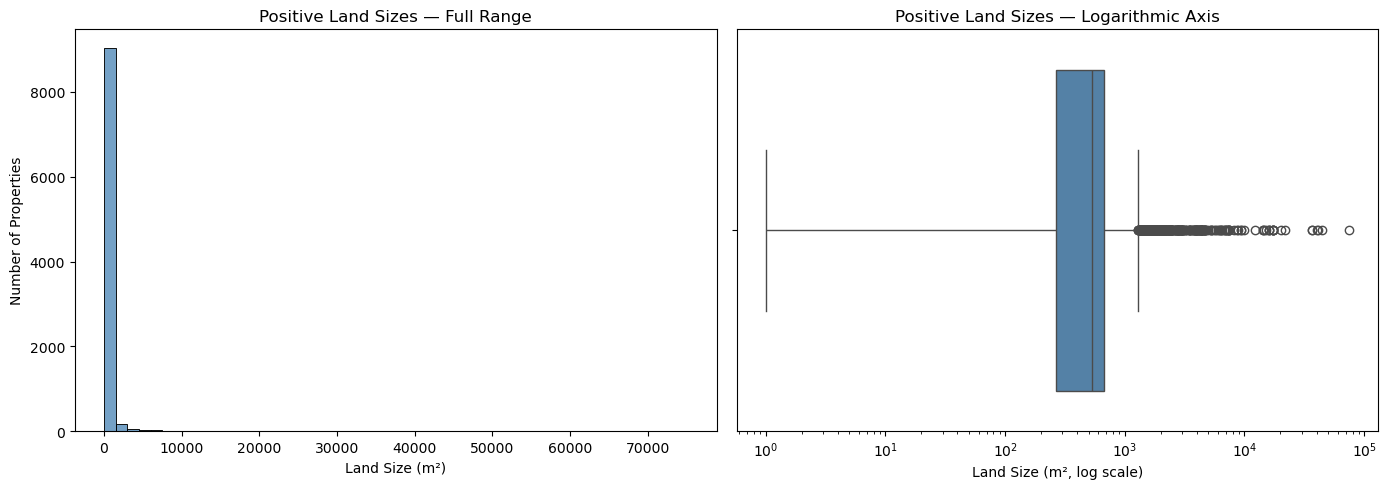

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    x=positive_landsize,
    bins=50,
    color="steelblue",
    edgecolor="black",
    ax=axes[0]
)

axes[0].set_title("Positive Land Sizes — Full Range")
axes[0].set_xlabel("Land Size (m²)")
axes[0].set_ylabel("Number of Properties")

sns.boxplot(
    x=positive_landsize,
    color="steelblue",
    ax=axes[1]
)

axes[1].set_xscale("log")
axes[1].set_title("Positive Land Sizes — Logarithmic Axis")
axes[1].set_xlabel("Land Size (m², log scale)")

plt.tight_layout()

figures_path = project_root / "results" / "figures"
figures_path.mkdir(parents=True, exist_ok=True)

plt.savefig(
    figures_path / "positive_landsize_distribution_and_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation

The full-range histogram shows a strong concentration of positive land sizes at the lower end and a long right tail. The extreme maximum creates wide histogram bins, limiting visibility of variation among typical properties.

The logarithmic-axis box plot makes the central range and large observations easier to distinguish. The median is 532 m², and the central 50% ranges from 267 m² to 675 m².

Using these quartiles, the IQR is 408 m², giving a lower boundary of -345 m² and an upper boundary of 1,287 m². Values above the upper boundary are potential outliers requiring investigation, rather than confirmed errors.

The minimum of 1 m² is not flagged by the IQR rule but still warrants contextual inspection. No records are removed or transformed based on these plots.

### 18.3 Quantify Potential Upper Land-Size Outliers

The IQR rule is applied to positive training land sizes to identify unusually large values. The count and percentage above the upper boundary are calculated relative to the positive land-size records.

These observations are flagged for investigation, not automatically treated as errors.

In [45]:
landsize_q1 = positive_landsize.quantile(0.25)
landsize_q3 = positive_landsize.quantile(0.75)

landsize_iqr = landsize_q3 - landsize_q1
landsize_upper_boundary = landsize_q3 + 1.5 * landsize_iqr

upper_landsize_count = (
    positive_landsize > landsize_upper_boundary
).sum()

upper_landsize_percentage = (
    upper_landsize_count / len(positive_landsize) * 100
)

print("Positive land-size records:", len(positive_landsize))
print(f"Q1: {landsize_q1:.2f} m²")
print(f"Q3: {landsize_q3:.2f} m²")
print(f"IQR: {landsize_iqr:.2f} m²")
print(f"Upper boundary: {landsize_upper_boundary:.2f} m²")
print("Potential upper outliers:", upper_landsize_count)
print(
    f"Percentage of positive records: "
    f"{upper_landsize_percentage:.2f}%"
)

Positive land-size records: 9296
Q1: 267.00 m²
Q3: 675.00 m²
IQR: 408.00 m²
Upper boundary: 1287.00 m²
Potential upper outliers: 322
Percentage of positive records: 3.46%


#### Observation

The IQR for positive training land sizes is 408 m², producing an upper boundary of 1,287 m². A total of 322 properties exceed this boundary, representing 3.46% of the 9,296 positive land-size records.

These observations are statistically unusual but are not confirmed data errors. Their property types, locations, building areas, and other available details will be inspected before deciding how to handle them. No records are removed or capped at this stage.

### 18.4 Inspect the Largest Land Sizes

The ten training properties with the largest land sizes above the IQR upper boundary are inspected alongside their location, property type, room count, building area, and price.

This inspection helps identify records requiring further verification. A large land size alone does not establish a data error.

In [46]:
landsize_inspection_columns = [
    "Suburb",
    "Address",
    "Type",
    "Rooms",
    "Landsize",
    "BuildingArea",
    "Price",
    "Distance",
    "Postcode",
    "CouncilArea",
    "Regionname"
]

largest_land_properties = (
    train_df.loc[
        train_df["Landsize"] > landsize_upper_boundary,
        landsize_inspection_columns
    ]
    .sort_values(
        by="Landsize",
        ascending=False
    )
    .head(10)
)

display(largest_land_properties)

tables_path = project_root / "results" / "tables"
tables_path.mkdir(parents=True, exist_ok=True)

largest_land_properties.to_csv(
    tables_path / "largest_land_size_properties.csv",
    index=True
)

,Suburb,Address,Type,Rooms,Landsize,BuildingArea,Price,Distance,Postcode,CouncilArea,Regionname
687,Balwyn North,9 Gildan St,h,3,75100.0,NaN,2000000.0,9.2,3104.0,Boroondara,Southern Metropolitan
13245,New Gisborne,71 Hamilton Rd,h,5,44500.0,44515.0,1355000.0,48.1,3438.0,NaN,Northern Victoria
5194,Reservoir,14 Beenak St,h,3,41400.0,NaN,572000.0,11.2,3073.0,Darebin,Northern Metropolitan
11371,Gisborne,21 Braeside Rd,h,4,40468.0,NaN,807000.0,45.9,3437.0,Macedon Ranges,Northern Victoria
3942,Maribyrnong,44/2 Horizon Dr,u,2,37000.0,NaN,495000.0,8.7,3032.0,Maribyrnong,Western Metropolitan
9223,Maribyrnong,2/6 Horizon Dr,u,2,37000.0,90.0,585000.0,4.3,3032.0,Maribyrnong,Western Metropolitan
8241,Port Melbourne,55/4 Seisman Pl,u,2,21715.0,99.0,1030000.0,3.8,3207.0,Port Phillip,Southern Metropolitan
12504,Gisborne,204 Panorama Dr,h,4,20200.0,189.0,780000.0,45.9,3437.0,NaN,Northern Victoria
5694,South Yarra,504/79 River St,u,2,17200.0,NaN,827000.0,3.3,3141.0,Stonnington,Southern Metropolitan
10819,South Yarra,308/800 Chapel St,u,2,17200.0,79.0,762500.0,2.7,3141.0,Stonnington,Southern Metropolitan


#### Observation

Inspection of the ten largest land-size records suggests several possible explanations for the extreme values.

Large plots in Gisborne are plausible given their outer-location context, although their accuracy has not been independently verified.

Several two-room units have recorded land sizes between 17,200 m² and 37,000 m². Where building area is available, it is much smaller (79–99 m²). These land sizes may describe a shared parcel or an entire development rather than land attributable to an individual unit. This interpretation remains unverified.

The Balwyn North and Reservoir house records warrant further investigation because of their unusually large land sizes relative to the available property context. The New Gisborne record also has a suspicious building area of 44,515 m² for a five-room house.

The inspected records should not all receive the same treatment. No values are corrected, removed, or capped at this stage, and findings from these ten records are not assumed to apply to all 322 flagged observations.

### 18.5 Compare Positive Land Sizes and Flagged Records by Property Type

Positive training land sizes are summarized separately for houses, townhouses, and units. Each group's count, median, maximum, and number of records above the overall positive-land-size IQR boundary are reported.

Flagged percentages are calculated within each property's type group. The same overall boundary is used for comparison; it is not a type-specific validity threshold.

In [47]:
landsize_by_type = train_df.loc[
    train_df["Landsize"] > 0,
    ["Type", "Landsize"]
].copy()

landsize_by_type["Above_Upper_Boundary"] = (
    landsize_by_type["Landsize"] > landsize_upper_boundary
)

landsize_type_summary = (
    landsize_by_type
    .groupby("Type")
    .agg(
        Positive_Count=("Landsize", "size"),
        Median_Landsize=("Landsize", "median"),
        Maximum_Landsize=("Landsize", "max"),
        Flagged_Count=("Above_Upper_Boundary", "sum")
    )
)

landsize_type_summary["Flagged_Percentage"] = (
    landsize_type_summary["Flagged_Count"]
    / landsize_type_summary["Positive_Count"]
    * 100
)

display(landsize_type_summary.round(2))

landsize_type_summary.to_csv(
    tables_path / "positive_landsize_summary_by_type.csv",
    index=True
)

,Positive_Count,Median_Landsize,Maximum_Landsize,Flagged_Count,Flagged_Percentage
Type,,,,,
h,7394,563.5,75100.0,95,1.28
t,784,224.0,15900.0,19,2.42
u,1118,288.0,37000.0,208,18.60


#### Observation

Among positive land-size records, 18.60% of units exceed the common upper boundary of 1,287 m², compared with 1.28% of houses and 2.42% of townhouses. Units account for 208 of the 322 flagged records, approximately 64.6%.

Together with the previously inspected unit records, this concentration supports the possibility that some unit land sizes describe shared parcels or entire developments. However, this interpretation is not confirmed.

The median positive land size is 563.5 m² for houses, 224 m² for townhouses, and 288 m² for units. These values should not be interpreted as directly comparable private land allocations without confirming the measurement definition.

This comparison excludes zero and missing values and uses an overall, rather than type-specific, IQR boundary. No records are removed or corrected based on these percentages.

### 18.6 Inspect the Smallest Positive Land Sizes

Inspect the ten smallest positive land-size records alongside property details to identify values requiring verification.

In [48]:
smallest_land_properties = (
    train_df.loc[
        train_df["Landsize"] > 0,
        landsize_inspection_columns
    ]
    .sort_values("Landsize")
    .head(10)
)

display(smallest_land_properties)

smallest_land_properties.to_csv(
    tables_path / "smallest_positive_land_size_properties.csv",
    index=True
)

,Suburb,Address,Type,Rooms,Landsize,BuildingArea,Price,Distance,Postcode,CouncilArea,Regionname
3318,Heidelberg West,190 Southern Rd,h,3,1.0,NaN,710000.0,9.4,3081.0,Banyule,Eastern Metropolitan
10581,Bentleigh,4/463 South Rd,u,2,1.0,62.0,380000.0,11.4,3204.0,Glen Eira,Southern Metropolitan
7710,Carnegie,2/13 Emily St,u,2,2.0,NaN,603000.0,11.4,3163.0,Glen Eira,Southern Metropolitan
8688,Toorak,32/637 Orrong Rd,t,3,3.0,131.0,1320000.0,4.6,3142.0,Stonnington,Southern Metropolitan
11144,Northcote,40 Gadd St,h,4,5.0,NaN,1955000.0,5.3,3070.0,Darebin,Northern Metropolitan
11507,South Yarra,4/4 Powell St,u,1,10.0,NaN,401500.0,2.7,3141.0,Stonnington,Southern Metropolitan
6019,Sunshine North,2/86 Phoenix St,u,2,14.0,NaN,315000.0,13.3,3020.0,Brimbank,Western Metropolitan
13267,Prahran,7 MacKay St,t,3,15.0,147.0,1463000.0,4.6,3181.0,NaN,Southern Metropolitan
8364,South Yarra,6/38 Chambers St,u,3,15.0,15.0,1320000.0,3.3,3141.0,Stonnington,Southern Metropolitan
10865,West Melbourne,125/33 Jeffcott St,u,2,17.0,90.0,670000.0,3.1,3003.0,Melbourne,Northern Metropolitan


#### Observation

The smallest positive land sizes include suspicious house records of 1–5 m² and townhouse records of 3–15 m². A three-room unit also has both land and building areas recorded as 15 m². These values require verification; no corrections or removals are made at this stage.

### 18.7 Land-Size Findings and Current Handling Decision

- Among positive land sizes, 322 records (3.46%) exceed the IQR upper boundary of 1,287 m².
- Large unit land sizes may represent shared parcels; some very small values and extreme house records require verification.
- Retain original values for now. Do not guess corrections, remove rows, or apply automatic clipping.
- Evaluate any proposed land-size treatment later using training cross-validation.

## 19. Building Area Distribution and Data Quality

### 19.1 Check Missing, Zero, and Negative Values

Count missing, zero, negative, and positive building-area values in the training data to establish their availability and identify values requiring inspection.

In [49]:
building_area = train_df["BuildingArea"]

print("Total training records:", len(building_area))
print("Missing values:", building_area.isna().sum())
print("Zero values:", (building_area == 0).sum())
print("Negative values:", (building_area < 0).sum())
print("Positive values:", (building_area > 0).sum())

Total training records: 10864
Missing values: 5129
Zero values: 15
Negative values: 0
Positive values: 5720


#### Observation

`BuildingArea` is missing for 5,129 of the 10,864 training records (47.21%). This substantial missingness means that analysis of the available values may not fully represent all properties; missingness patterns should therefore be examined before selecting an imputation strategy.

There are 15 zero values and no negative values. The zeros require contextual inspection before being treated as valid measurements or missing information. The remaining 5,720 positive values will be used to examine the distribution and potential extremes. No values are modified at this stage.

### 19.2 Summarize Positive Building Areas

Summary statistics and upper percentiles are calculated for positive training `BuildingArea` values to examine their typical range, spread, and potential extremes. Missing and zero values are excluded only from this summary; the original data remains unchanged.

In [50]:
positive_building_area = train_df.loc[
    train_df["BuildingArea"] > 0,
    "BuildingArea"
]

display(
    positive_building_area.describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    ).round(2)
)

count     5720.00
mean       154.40
std        602.43
min          1.00
25%         93.00
50%        126.00
75%        175.00
90%        240.10
95%        292.00
99%        466.62
max      44515.00
Name: BuildingArea, dtype: float64

#### Observation

Among the 5,720 positive building-area records, the median is 126 m² and the central 50% ranges from 93 m² to 175 m². The mean of 154.40 m² exceeds the median, while the large standard deviation of 602.43 m² indicates substantial sensitivity to extreme upper values.

The maximum of 44,515 m² is approximately 95 times the 99th percentile of 466.62 m² and corresponds to the New Gisborne record identified during land-size inspection. This value, along with the minimum of 1 m², requires further verification. These statistics describe only records with positive building areas; no values are corrected or removed at this stage.

### 19.3 Visualize Positive Building Areas

A full-range histogram and a box plot with a logarithmic x-axis are used to examine positive building areas. The histogram shows the overall range, while the logarithmic axis helps distinguish the central spread from extreme observations.

The log scale changes only the display; the original measurements remain unchanged.

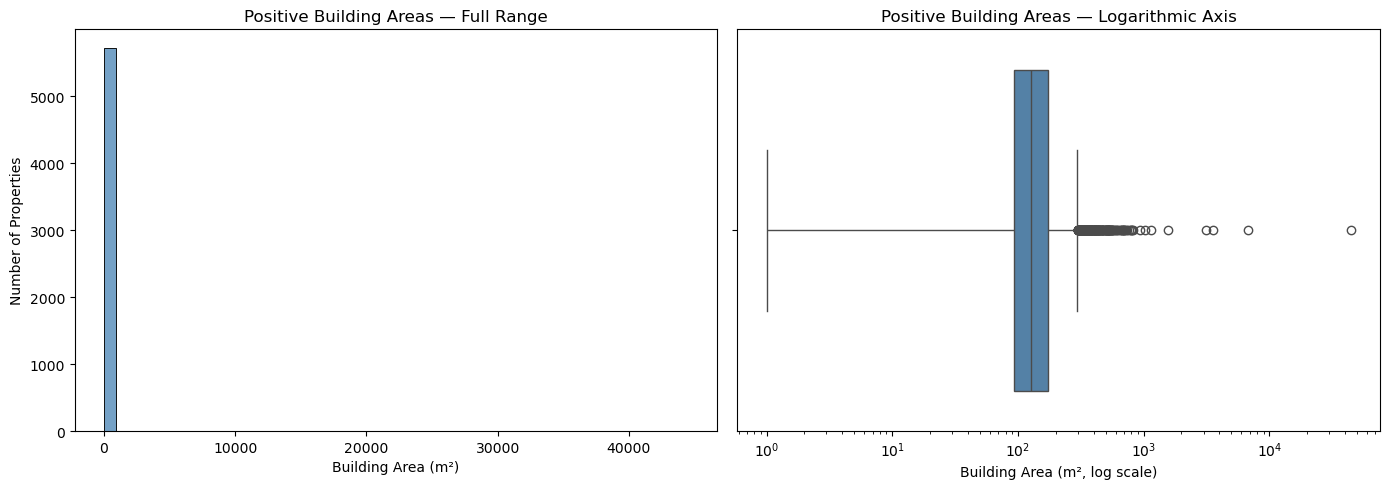

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    x=positive_building_area,
    bins=50,
    color="steelblue",
    edgecolor="black",
    ax=axes[0]
)

axes[0].set_title("Positive Building Areas — Full Range")
axes[0].set_xlabel("Building Area (m²)")
axes[0].set_ylabel("Number of Properties")

sns.boxplot(
    x=positive_building_area,
    color="steelblue",
    ax=axes[1]
)

axes[1].set_xscale("log")
axes[1].set_title("Positive Building Areas — Logarithmic Axis")
axes[1].set_xlabel("Building Area (m², log scale)")

plt.tight_layout()

plt.savefig(
    figures_path / "positive_building_area_distribution_and_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation

The full-range histogram is dominated by the first bin because the extreme maximum produces wide intervals, obscuring variation among typical building areas. The logarithmic-axis box plot shows a central range of 93–175 m² and a long upper tail, with the maximum of 44,515 m² clearly separated from the remaining observations.

The IQR rule gives an upper boundary of 298 m². Values above this threshold require investigation but are not automatically errors. The minimum of 1 m² is not flagged by the lower IQR boundary of -30 m², illustrating the need for contextual checks alongside statistical rules. No values are modified at this stage.

### 19.4 Quantify Potential Upper Building-Area Outliers

The IQR rule is applied to positive training building areas to quantify observations above the upper boundary. Their percentage is calculated relative to posi
tive building-area records. These observations are flagged for further inspection rather than classified as errors.

In [52]:
building_area_q1 = positive_building_area.quantile(0.25)
building_area_q3 = positive_building_area.quantile(0.75)

building_area_iqr = building_area_q3 - building_area_q1
building_area_upper_boundary = (
    building_area_q3 + 1.5 * building_area_iqr
)

upper_building_area_count = (
    positive_building_area > building_area_upper_boundary
).sum()

upper_building_area_percentage = (
    upper_building_area_count / len(positive_building_area) * 100
)

print("Positive building-area records:", len(positive_building_area))
print(f"Q1: {building_area_q1:.2f} m²")
print(f"Q3: {building_area_q3:.2f} m²")
print(f"IQR: {building_area_iqr:.2f} m²")
print(f"Upper boundary: {building_area_upper_boundary:.2f} m²")
print("Potential upper outliers:", upper_building_area_count)
print(
    f"Percentage of positive records: "
    f"{upper_building_area_percentage:.2f}%"
)

Positive building-area records: 5720
Q1: 93.00 m²
Q3: 175.00 m²
IQR: 82.00 m²
Upper boundary: 298.00 m²
Potential upper outliers: 274
Percentage of positive records: 4.79%


#### Observation

The IQR of positive building areas is 82 m², giving an upper boundary of 298 m². A total of 274 records exceed this threshold, representing 4.79% of the 5,720 positive observations.

This flagged group may include both valid large buildings and recording anomalies. The threshold alone cannot distinguish between them, so the largest records will be examined alongside property type, room count, land size, and location before deciding their treatment.

### 19.5 Inspect the Largest Building Areas

The ten largest training building areas above the IQR upper boundary are examined alongside property type, room count, land size, price, and location. This provides context for distinguishing plausible large buildings from records requiring further verification.

In [53]:
building_area_inspection_columns = [
    "Suburb",
    "Address",
    "Type",
    "Rooms",
    "BuildingArea",
    "Landsize",
    "Price",
    "Distance",
    "YearBuilt"
]

largest_building_properties = (
    train_df.loc[
        train_df["BuildingArea"] > building_area_upper_boundary,
        building_area_inspection_columns
    ]
    .sort_values("BuildingArea", ascending=False)
    .head(10)
)

display(largest_building_properties)

largest_building_properties.to_csv(
    tables_path / "largest_building_area_properties.csv",
    index=True
)

,Suburb,Address,Type,Rooms,BuildingArea,Landsize,Price,Distance,YearBuilt
13245,New Gisborne,71 Hamilton Rd,h,5,44515.0000,44500.0,1355000.0,48.1,NaN
1484,Bulleen,19 Warringal St,h,4,6791.0000,732.0,1280000.0,11.8,NaN
2560,Fitzroy North,186 Queens Pde,t,2,3558.0000,2778.0,930000.0,3.5,NaN
1588,Camberwell,46 Athelstan Rd,h,5,3112.0000,730.0,2608000.0,7.8,1920.0
2234,Elsternwick,5/16 St Georges Rd,u,2,1561.0000,0.0,741000.0,8.5,1966.0
2830,Glen Iris,1/58 Edgar St N,t,2,1143.0000,0.0,600000.0,9.2,NaN
3640,Kew,24 Fitzwilliam St,h,5,1022.0000,531.0,1975000.0,5.6,1890.0
12064,Lalor,52 Monash St,h,3,934.0000,532.0,580500.0,16.3,1980.0
10920,Brighton,23 Arthur Av,h,5,826.8367,818.0,3000000.0,10.5,NaN
7172,Ormond,9 Queen St,h,4,808.0000,805.0,1920000.0,11.8,1925.0


#### Observation

Several of the largest building-area records are inconsistent with their reported room counts or warrant closer examination. Examples include a five-room house with 44,515 m² in New Gisborne, a four-room house with 6,791 m² on 732 m² of land in Bulleen, and a two-room townhouse with 3,558 m² in Fitzroy North.

The two-room Elsternwick and Glen Iris properties also have unusually large building areas of 1,561 m² and 1,143 m². Their zero land-size entries prevent meaningful building-to-land comparisons.

These patterns suggest possible measurement or recording issues, but do not establish specific corrections. Building area exceeding land size is not sufficient evidence of an error because floor area may span multiple storeys. The records remain unchanged pending verification.

### 19.6 Inspect the Smallest Positive Building Areas

The ten smallest positive training building areas are inspected alongside room counts, property types, and other available details. This helps identify implausibly small measurements that may not be flagged by the IQR rule.

In [54]:
smallest_building_properties = (
    train_df.loc[
        train_df["BuildingArea"] > 0,
        building_area_inspection_columns
    ]
    .sort_values("BuildingArea")
    .head(10)
)

display(smallest_building_properties)

smallest_building_properties.to_csv(
    tables_path / "smallest_positive_building_area_properties.csv",
    index=True
)

,Suburb,Address,Type,Rooms,BuildingArea,Landsize,Price,Distance,YearBuilt
5306,Richmond,5/285 Punt Rd,u,1,1.0,0.0,342000.0,2.6,1970.0
1371,Brunswick,329 Brunswick Rd,h,4,1.0,319.0,1175000.0,5.2,NaN
11931,Camberwell,2/37 Thomas St,u,2,1.0,1625.0,600800.0,7.7,1960.0
4386,North Melbourne,11/19 Wood St,u,2,1.0,0.0,587134.0,2.3,1970.0
11883,Balwyn,27 Burroughs Rd,h,5,1.0,729.0,3812000.0,7.9,2012.0
8297,Reservoir,3/138 Rathcown Rd,t,3,1.0,213.0,815000.0,11.2,2012.0
11578,Ashwood,47B Vannam Dr,t,3,1.0,343.0,1060000.0,10.2,2000.0
2938,Glenroy,4/36 Acacia St,t,2,2.0,190.0,488500.0,13.0,NaN
8900,North Melbourne,187 Errol St,h,2,2.0,91.0,962000.0,1.8,NaN
1765,Carnegie,2 Poplar Gr,h,2,2.0,316.0,907000.0,11.4,NaN


#### Observation

The ten smallest positive building areas are all 1–2 m² and occur across houses, townhouses, and units. These measurements are implausible as total building areas given the reported room counts, including a five-room house in Balwyn and a four-room house in Brunswick, both recorded as 1 m².

The values may reflect recording errors or placeholders, but their intended measurements cannot be established from the available fields. They are flagged as suspected invalid measurements for the preprocessing review; no replacement values are guessed. This also demonstrates why contextual checks are necessary when the IQR rule does not flag unusually small positive values.

### 19.7 Inspect Zero Building-Area Records

All training records with zero building area are inspected alongside property type, room count, land size, and other available details. This helps assess whether zero represents a meaningful measurement or potentially unavailable information.

In [55]:
zero_building_properties = train_df.loc[
    train_df["BuildingArea"] == 0,
    building_area_inspection_columns
].copy()

print("Zero building-area records:", len(zero_building_properties))

display(zero_building_properties)

zero_building_properties.to_csv(
    tables_path / "zero_building_area_properties.csv",
    index=True
)

Zero building-area records: 15


,Suburb,Address,Type,Rooms,BuildingArea,Landsize,Price,Distance,YearBuilt
13411,Epping,26 Lowalde Dr,h,3,0.0,536.0,595000.0,19.6,1980.0
13370,Brighton East,60 Cummins Rd,h,3,0.0,623.0,1650000.0,10.3,1920.0
13472,Kilsyth,17 Birkenhead Dr,h,3,0.0,862.0,803000.0,26.0,1970.0
12226,Balwyn North,14 Wanbrow Av,h,5,0.0,743.0,1950000.0,9.7,1949.0
13499,Moorabbin,7 Walsh Av,h,3,0.0,580.0,1290000.0,14.3,1970.0
12395,Roxburgh Park,16 Sandover Dr,h,4,0.0,504.0,570000.0,20.6,2000.0
13468,Kew,16 Hodgson St,h,5,0.0,668.0,3450000.0,5.4,2006.0
13040,Prahran,6 Aberdeen Rd,h,3,0.0,125.0,1390000.0,4.6,2002.0
13521,Port Melbourne,44 Garton St,t,4,0.0,123.0,2455000.0,3.5,2010.0
13402,Craigieburn,28 Powell St,h,3,0.0,197.0,412500.0,20.6,2012.0


#### Observation

All 15 zero-building-area records are houses or townhouses (13 houses and 2 townhouses), with 3–5 rooms, positive land sizes, and recorded construction years. These details are inconsistent with a literal building area of zero and suggest unavailable or incorrectly recorded measurements.

During preprocessing, these zeros will be recoded as missing values while retaining the property records. This will increase the missing building-area count from 5,129 to 5,144, before any other cleaning decisions. Imputation will be fitted within training cross-validation folds to avoid leakage; the original data remains unchanged during EDA.

### 19.8 Compare Building-Area Missingness by Property Type

Original missing values and zero building areas are summarized separately for each property type. A combined unavailable-area percentage reflects the decision to treat zeros as missing during preprocessing.

Percentages use the total records within each property type. This analysis examines whether data availability differs across types; it does not establish the missingness mechanism.

In [56]:
building_missingness = train_df[["Type", "BuildingArea"]].copy()

building_missingness["Is_Missing"] = (
    building_missingness["BuildingArea"].isna()
)

building_missingness["Is_Zero"] = (
    building_missingness["BuildingArea"] == 0
)

building_missingness_summary = (
    building_missingness
    .groupby("Type")
    .agg(
        Total_Records=("BuildingArea", "size"),
        Missing_Count=("Is_Missing", "sum"),
        Zero_Count=("Is_Zero", "sum")
    )
)

building_missingness_summary["Unavailable_Count"] = (
    building_missingness_summary["Missing_Count"]
    + building_missingness_summary["Zero_Count"]
)

building_missingness_summary["Unavailable_Percentage"] = (
    building_missingness_summary["Unavailable_Count"]
    / building_missingness_summary["Total_Records"]
    * 100
)

display(building_missingness_summary.round(2))

building_missingness_summary.to_csv(
    tables_path / "building_area_missingness_by_type.csv",
    index=True
)

,Total_Records,Missing_Count,Zero_Count,Unavailable_Count,Unavailable_Percentage
Type,,,,,
h,7532,3625,13,3638,48.30
t,903,354,2,356,39.42
u,2429,1150,0,1150,47.34


#### Observation

After counting zero building areas as unavailable, the unavailable proportions are 48.30% for houses, 39.42% for townhouses, and 47.34% for units. Townhouses have better coverage, although missingness remains substantial across all three types.

These differences indicate that building-area availability varies by property type, but they do not establish the missingness mechanism. Property type is therefore a relevant candidate for evaluating imputation strategies. A missing-value indicator may also be tested using training cross-validation. These counts exclude suspicious positive measurements, whose treatment remains unresolved.

###  Building-Area Findings and Current Handling

`BuildingArea` is missing in 5,129 of 10,864 training records (47.21%). A further 15 records contain zero, which is implausible given their property types and room counts. During preprocessing, these zeros will be treated as missing, bringing unavailable values to 5,144 records (47.35%).

Among the 5,720 positive values, 274 (4.79%) exceed the IQR upper boundary of 298 m². Inspection also identified suspiciously large and small measurements. These records are flagged for review; the IQR rule alone does not confirm errors.

For now, retain the rows and do not guess replacement values. Test missing-value handling, missingness indicators, and any justified treatment of suspicious measurements within training cross-validation. Keep the original data unchanged during EDA.

## 20. YearBuilt Distribution and Plausibility

### 20.1 Summarize `YearBuilt`

Check missingness, unique year count, and summary statistics in the training data to identify values that may need contextual inspection.

In [57]:
year_built = train_df["YearBuilt"]

print("Training records:", len(year_built))
print("Missing values:", year_built.isna().sum())
print("Unique recorded years:", year_built.nunique())

display(year_built.describe().round(2))

Training records: 10864
Missing values: 4286
Unique recorded years: 139


count    6578.00
mean     1965.10
std        36.37
min      1830.00
25%      1940.00
50%      1970.00
75%      2000.00
max      2018.00
Name: YearBuilt, dtype: float64

#### Observation

`YearBuilt` is available for 6,578 training records, with 4,286 missing values (39.45%) and 139 unique recorded years. Available construction years range from 1830 to 2018, with a median of 1970 and an interquartile range of 1940–2000.

The earliest and latest years require contextual inspection rather than automatic removal. Construction years will also be compared with each property's sale year to identify chronological inconsistencies before deriving property age. These statistics describe only records with an available construction year.

### 20.2 Inspect the Earliest and Latest Construction Years

The five earliest and five latest recorded construction years in the training data are inspected alongside sale dates and property details. These records provide context for assessing extreme years and identifying possible chronological inconsistencies.

In [58]:
year_inspection_columns = [
    "Suburb",
    "Address",
    "Type",
    "Rooms",
    "YearBuilt",
    "Date",
    "BuildingArea",
    "Price"
]

recorded_year_properties = train_df.loc[
    train_df["YearBuilt"].notna(),
    year_inspection_columns
]

earliest_year_properties = (
    recorded_year_properties
    .sort_values("YearBuilt")
    .head(5)
)

latest_year_properties = (
    recorded_year_properties
    .sort_values("YearBuilt", ascending=False)
    .head(5)
)

print("Earliest construction years:")
display(earliest_year_properties)

print("Latest construction years:")
display(latest_year_properties)

earliest_year_properties.to_csv(
    tables_path / "earliest_construction_year_properties.csv",
    index=True
)

latest_year_properties.to_csv(
    tables_path / "latest_construction_year_properties.csv",
    index=True
)

Earliest construction years:


,Suburb,Address,Type,Rooms,YearBuilt,Date,BuildingArea,Price
2079,Collingwood,2/79 Oxford St,u,2,1830.0,3/09/2016,122.0,855000.0
5860,St Kilda,51/167 Fitzroy St,u,3,1850.0,25/02/2017,3.0,1600000.0
5405,Richmond,22a Stanley St,h,3,1850.0,24/09/2016,144.0,1600000.0
2530,Fitzroy,52 Nicholson St,h,4,1854.0,13/08/2016,291.0,3310000.0
5536,South Melbourne,352 Moray St,h,4,1856.0,7/05/2016,232.0,2260000.0


Latest construction years:


,Suburb,Address,Type,Rooms,YearBuilt,Date,BuildingArea,Price
1234,Brighton East,8 Thomas St,h,2,2018.0,24/09/2016,250.0,1310000.0
5153,Reservoir,89 Darebin Bvd,h,4,2017.0,17/09/2016,129.0,767500.0
12665,Brunswick,5 McPherson St,h,4,2017.0,16/09/2017,288.0,1820000.0
7060,Heidelberg,36 Buckingham Dr,h,3,2017.0,30/07/2016,357.0,1030000.0
11136,Newport,50 Peel St,h,3,2017.0,12/08/2017,NaN,1195000.0


#### Observation

The earliest inspected construction years range from 1830 to 1856. Their age alone does not establish a recording error, although the dates remain unverified. The St Kilda record also contains a suspicious building area of 3 m² for three rooms, which is a separate data-quality concern.

Three of the five latest-year records have construction years later than their sale years: one by two years and two by one year. These would produce negative ages when calculated as sale year minus construction year. Possible explanations include recording errors or planned construction, but the available fields cannot distinguish between them. All training records will therefore be checked for this pattern before deriving property age.

### 20.3 Check Construction Years Against Sale Years

Sale dates are parsed using day/month/year format and compared with recorded construction years. Records with construction years later than their sale years are flagged for review. Missing or unparseable dates are reported separately.

In [59]:
year_check = train_df[year_inspection_columns].copy()

year_check["Sale_Date"] = pd.to_datetime(
    year_check["Date"],
    format="%d/%m/%Y",
    errors="coerce"
)

year_check["Sale_Year"] = year_check["Sale_Date"].dt.year

year_check["Age_At_Sale"] = (
    year_check["Sale_Year"] - year_check["YearBuilt"]
)

comparable_records = (
    year_check["YearBuilt"].notna()
    & year_check["Sale_Year"].notna()
)

future_construction = year_check.loc[
    comparable_records & (year_check["Age_At_Sale"] < 0)
].copy()

print("Missing original sale dates:", year_check["Date"].isna().sum())

print(
    "Unparseable non-missing sale dates:",
    (
        year_check["Date"].notna()
        & year_check["Sale_Date"].isna()
    ).sum()
)

print("Records with both years available:", comparable_records.sum())
print("Construction year after sale year:", len(future_construction))

display(
    future_construction[
        year_inspection_columns + ["Sale_Year", "Age_At_Sale"]
    ]
)

future_construction.to_csv(
    tables_path / "construction_year_after_sale_year.csv",
    index=True
)

Missing original sale dates: 0
Unparseable non-missing sale dates: 0
Records with both years available: 6578
Construction year after sale year: 6


,Suburb,Address,Type,Rooms,YearBuilt,Date,BuildingArea,Price,Sale_Year,Age_At_Sale
7060,Heidelberg,36 Buckingham Dr,h,3,2017.0,30/07/2016,357.0,1030000.0,2016,-1.0
5153,Reservoir,89 Darebin Bvd,h,4,2017.0,17/09/2016,129.0,767500.0,2016,-1.0
1234,Brighton East,8 Thomas St,h,2,2018.0,24/09/2016,250.0,1310000.0,2016,-2.0
441,Avondale Heights,157 Canning St,t,3,2017.0,3/12/2016,181.0,851000.0,2016,-1.0
3489,Keilor East,20 Keith Gr,h,3,2017.0,23/04/2016,126.0,825000.0,2016,-1.0
4282,Newport,7 Durkin St,h,3,2017.0,28/05/2016,190.0,945000.0,2016,-1.0


#### Observation

All training sale dates were parsed successfully, and 6,578 records have both sale and construction years available. Six records (0.09% of comparable observations) have construction years later than their sale years: five by one year and one by two years.

These differences may reflect planned construction or recording errors; the available fields do not establish the cause. For a derived property-age feature, negative ages will be treated as missing while retaining the rows and preserving the original construction years for review. Any required imputation will be fitted within training cross-validation folds.

###  YearBuilt Findings and Handling Decisions

`YearBuilt` is missing for 4,286 training records (39.45%). Recorded years range from 1830 to 2018. Early construction years will not be removed solely because of their age; inspected extreme years remain unverified.

If property age is used, it will be calculated as sale year minus construction year. The six negative ages will be treated as missing, giving 4,292 unavailable ages before imputation. A zero age means construction and sale occurred in the same calendar year and will be retained.

Original construction years and property records will be preserved. Imputation and the choice between `YearBuilt` and derived property age will be evaluated within training cross-validation.

## 21. Numerical Relationships and Feature Redundancy

### 21.1 Compare Numerical Features with Price

Pearson and Spearman correlations are calculated using training data to compare linear and monotonic associations with price. Available-pair counts are reported because missingness differs across features.

These are exploratory associations based on the recorded values, including unresolved suspicious measurements. Correlation alone will not determine feature selection.

In [60]:
relationship_features = [
    "Rooms",
    "Bedroom2",
    "Bathroom",
    "Car",
    "Distance",
    "Landsize",
    "BuildingArea",
    "YearBuilt",
    "Propertycount"
]

correlation_rows = []

for feature in relationship_features:
    available_pairs = train_df[[feature, "Price"]].dropna()

    correlation_rows.append({
        "Feature": feature,
        "Available_Pairs": len(available_pairs),
        "Pearson": available_pairs[feature].corr(
            available_pairs["Price"], method="pearson"
        ),
        "Spearman": available_pairs[feature].corr(
            available_pairs["Price"], method="spearman"
        )
    })

price_correlations = pd.DataFrame(correlation_rows)

display(price_correlations.round(3))

price_correlations.to_csv(
    tables_path / "numerical_feature_price_correlations.csv",
    index=False
)

,Feature,Available_Pairs,Pearson,Spearman
0,Rooms,10864,0.494,0.540
1,Bedroom2,10864,0.472,0.523
2,Bathroom,10864,0.463,0.429
3,Car,10814,0.229,0.284
4,Distance,10864,-0.162,-0.130
5,Landsize,10864,0.048,0.327
6,BuildingArea,5735,0.082,0.627
7,YearBuilt,6578,-0.332,-0.365
8,Propertycount,10864,-0.046,-0.019


#### Observation

Rooms, bedrooms, and bathrooms show positive associations with price. Building area has the strongest positive Spearman correlation among the examined features (0.627), despite a weak Pearson correlation (0.082). Land size shows a similar contrast (0.327 versus 0.048). These differences warrant checking the influence of extreme measurements, non-linearity, and property-type differences.

YearBuilt is negatively associated with price, while Distance and Propertycount have weak overall correlations. These unadjusted associations do not establish causal effects or justify dropping features.

Available-pair counts vary because of missingness. Building-area correlations include 15 zero values and unresolved suspicious measurements, so they will be reassessed after the documented cleaning decisions are implemented.

### 21.2 Examine Correlations Between Numerical Predictors

A Pearson correlation matrix is calculated on training predictors to identify potential linear redundancy, particularly between room and bedroom counts. Each correlation uses available paired observations.

Strong correlations indicate candidates for further review, rather than automatic feature removal. Unresolved measurement issues may affect the results.

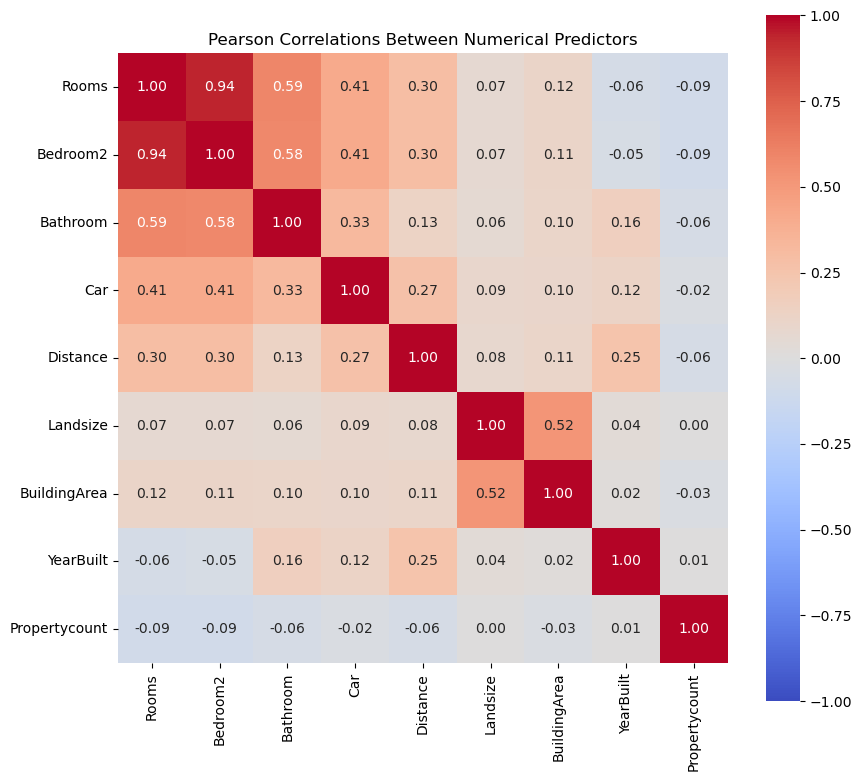

In [63]:
predictor_correlations = train_df[relationship_features].corr(
    method="pearson"
)

fig, ax = plt.subplots(figsize=(9, 8))

sns.heatmap(
    predictor_correlations,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    ax=ax
)

ax.set_title("Pearson Correlations Between Numerical Predictors")

plt.tight_layout()

plt.savefig(
    figures_path / "numerical_predictor_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

predictor_correlations.to_csv(
    tables_path / "numerical_predictor_correlations.csv",
    index=True
)

#### Observation

Rooms and Bedroom2 have a strong Pearson correlation of 0.94, indicating substantial shared information and potential coefficient instability when both are used in a linear model. Their row-level agreement will be examined before considering either feature for removal.

Rooms and Bedroom2 have moderate correlations with Bathroom (0.59 and 0.58). Landsize and BuildingArea are also moderately correlated (0.52), although unresolved extreme measurements may influence this estimate.

This matrix provides an initial redundancy check. Pairwise correlations alone do not fully diagnose multicollinearity, and feature decisions will be assessed using training cross-validation.

### 21.3 Check Agreement Between Rooms and Bedroom2

Exact agreement and differences between `Rooms` and `Bedroom2` are examined in training records where both values are available. This helps assess potential redundancy and identify discrepancies before making a feature-selection decision.

In [64]:
room_comparison = train_df[
    ["Rooms", "Bedroom2"]
].dropna().copy()

room_comparison["Difference"] = (
    room_comparison["Rooms"] - room_comparison["Bedroom2"]
)

matching_count = (room_comparison["Difference"] == 0).sum()
different_count = (room_comparison["Difference"] != 0).sum()

matching_percentage = (
    matching_count / len(room_comparison) * 100
)

print("Comparable records:", len(room_comparison))
print("Matching counts:", matching_count)
print("Different counts:", different_count)
print(f"Exact agreement: {matching_percentage:.2f}%")

difference_summary = (
    room_comparison["Difference"]
    .value_counts()
    .sort_index()
    .rename_axis("Rooms_minus_Bedroom2")
    .reset_index(name="Property_Count")
)

display(difference_summary)

difference_summary.to_csv(
    tables_path / "rooms_bedroom2_agreement.csv",
    index=False
)

Comparable records: 10864
Matching counts: 10328
Different counts: 536
Exact agreement: 95.07%


,Rooms_minus_Bedroom2,Property_Count
0,-17.0,1
1,-6.0,1
2,-5.0,1
3,-3.0,2
4,-2.0,14
5,-1.0,144
6,0.0,10328
7,1.0,315
8,2.0,44
9,3.0,10


#### Observation

Rooms and Bedroom2 agree exactly in 10,328 of 10,864 training records (95.07%), supporting the substantial redundancy suggested by their correlation of 0.94. Of the 536 disagreements, 459 differ by one and 77 differ by two or more.

The largest discrepancy is -17 for Rooms minus Bedroom2, indicating a potentially inconsistent record requiring inspection. Agreement alone does not establish which field is more reliable. Extreme discrepancies will be reviewed, and retaining Rooms alone versus both predictors will be evaluated using training cross-validation.

### 21.4 Inspect the Largest Room-Count Discrepancies

Training records with an absolute difference of at least two between `Rooms` and `Bedroom2` are identified. The ten largest discrepancies are inspected alongside property details to assess possible inconsistencies. This threshold prioritizes inspection and is not a rule for declaring errors.

In [65]:
room_discrepancies = train_df[
    [
        "Suburb", "Address", "Type",
        "Rooms", "Bedroom2", "Bathroom",
        "BuildingArea", "Price"
    ]
].dropna(subset=["Rooms", "Bedroom2"]).copy()

room_discrepancies["Difference"] = (
    room_discrepancies["Rooms"] - room_discrepancies["Bedroom2"]
)

room_discrepancies["Absolute_Difference"] = (
    room_discrepancies["Difference"].abs()
)

large_room_discrepancies = (
    room_discrepancies.loc[
        room_discrepancies["Absolute_Difference"] >= 2
    ]
    .sort_values("Absolute_Difference", ascending=False)
)

print("Records with absolute difference >= 2:", len(large_room_discrepancies))

display(large_room_discrepancies.head(10))

large_room_discrepancies.to_csv(
    tables_path / "large_rooms_bedroom2_discrepancies.csv",
    index=True
)

Records with absolute difference >= 2: 77


,Suburb,Address,Type,Rooms,Bedroom2,Bathroom,BuildingArea,Price,Difference,Absolute_Difference
7404,Caulfield East,5 Grange Rd,h,3,20.0,1.0,NaN,1650000.0,-17.0,17.0
6915,Fawkner,39 Lynch Rd,h,3,9.0,6.0,103.0,751000.0,-6.0,6.0
4980,Preston,421 Murray Rd,h,4,9.0,8.0,280.0,760000.0,-5.0,5.0
3360,Ivanhoe,20 Locksley Rd,h,4,0.0,2.0,201.0,2400000.0,4.0,4.0
1926,Coburg,35 The Grove,u,8,4.0,2.0,NaN,2250000.0,4.0,4.0
8301,Reservoir,96b Cheddar Rd,h,4,0.0,1.0,NaN,678500.0,4.0,4.0
8998,Airport West,8 Kittyhawk St,h,4,0.0,3.0,NaN,1026000.0,4.0,4.0
5459,Rosanna,180 Grandview Gr,h,6,3.0,3.0,NaN,1245000.0,3.0,3.0
3339,Hughesdale,159 Warrigal Rd,h,4,1.0,1.0,NaN,900000.0,3.0,3.0
913,Bentleigh East,579 Warrigal Rd,h,3,0.0,0.0,NaN,700000.0,3.0,3.0


#### Observation

The largest discrepancies include a property with Rooms = 3 and Bedroom2 = 20, two properties with Bedroom2 = 9 but Rooms = 3–4, and several houses with positive room counts but zero recorded bedrooms. Some records also contain unusual bathroom counts, indicating concerns beyond a single field.

These inconsistencies require verification and do not establish which column is correct. Combined with 95.07% exact agreement, the findings support evaluating Rooms alone as a simpler baseline and testing whether Bedroom2 adds predictive value through training cross-validation. No counts are automatically overwritten and no rows are removed.

## 22. Categorical Features and Price Patterns

### 22.1 Review Category Counts and Missingness

Summarize unique categories and missing values in the training data to guide categorical preprocessing. Postcode is treated as a location category. Address is included to assess its suitability as a predictor.

In [68]:
categorical_features = [
    "Type", "Method", "Regionname", "CouncilArea",
    "Suburb", "Postcode", "SellerG", "Address"
]

categorical_summary = pd.DataFrame({
    "Unique_Categories": train_df[categorical_features].nunique(),
    "Missing_Count": train_df[categorical_features].isna().sum(),
    "Missing_Percentage": (
        train_df[categorical_features].isna().mean() * 100
    ).round(2)
})

categorical_summary.index.name = "Feature"

display(categorical_summary)

categorical_summary.to_csv(
    tables_path / "categorical_feature_summary.csv"
)

,Unique_Categories,Missing_Count,Missing_Percentage
Feature,,,
Type,3,0,0.00
Method,5,0,0.00
Regionname,8,0,0.00
CouncilArea,33,1090,10.03
Suburb,306,0,0.00
Postcode,192,0,0.00
SellerG,249,0,0.00
Address,10726,0,0.00


#### Observation

`Type`, `Method`, and `Regionname` contain 3, 5, and 8 categories, respectively, making them manageable candidates for one-hot encoding. `CouncilArea` is the only reviewed categorical feature with missing values: 1,090 records (10.03%). These will initially be represented by an `Unknown` category.

`Suburb`, `Postcode`, and `SellerG` contain substantially more categories, so category frequencies should be considered when planning encoding. `Address` has 10,726 unique values across 10,864 training records and will be excluded from the initial baseline because direct one-hot encoding would create mostly property-specific features with limited support.

Categorical encoders will be fitted within each training fold and configured to handle unseen categories.

### 22.2 Compare Prices by Property Type

Summarize training property counts and median prices for houses (`h`), townhouses (`t`), and units (`u`). Group sizes provide context for interpreting price differences.

In [69]:
type_price_summary = (
    train_df.groupby("Type")
    .agg(
        Property_Count=("Price", "size"),
        Median_Price=("Price", "median")
    )
)

type_price_summary["Percentage"] = (
    type_price_summary["Property_Count"] / len(train_df) * 100
).round(2)

display(type_price_summary)

type_price_summary.to_csv(
    tables_path / "property_type_price_summary.csv"
)

,Property_Count,Median_Price,Percentage
Type,,,
h,7532,1080000.0,69.33
t,903,860000.0,8.31
u,2429,560000.0,22.36


#### Observation

Houses account for 69.33% of training properties and have the highest median price at AUD 1,080,000, followed by townhouses at AUD 860,000 and units at AUD 560,000. Townhouses are the smallest group, representing 8.31% of records.

These differences support retaining `Type` as a candidate predictor. However, they are unadjusted comparisons: location, property size, and other characteristics may also explain the price differences. Model evaluation should include performance by property type because overall metrics will be influenced most by houses.

### 22.3 Compare Prices by Region

Summarize training property counts and median prices across regions. Group sizes are reported because medians from sparsely represented regions may be less stable.

In [70]:
region_price_summary = (
    train_df.groupby("Regionname")
    .agg(
        Property_Count=("Price", "size"),
        Median_Price=("Price", "median")
    )
    .sort_values("Median_Price", ascending=False)
)

region_price_summary["Percentage"] = (
    region_price_summary["Property_Count"] / len(train_df) * 100
).round(2)

display(region_price_summary)

region_price_summary.to_csv(
    tables_path / "region_price_summary.csv"
)

,Property_Count,Median_Price,Percentage
Regionname,,,
Southern Metropolitan,3758,1250000.0,34.59
Eastern Metropolitan,1169,1010000.0,10.76
South-Eastern Metropolitan,366,850250.0,3.37
Northern Metropolitan,3119,810000.0,28.71
Western Metropolitan,2354,790000.0,21.67
Eastern Victoria,37,683000.0,0.34
Northern Victoria,34,537500.0,0.31
Western Victoria,27,395000.0,0.25


#### Observation

Median prices vary across regions, from AUD 1,250,000 in Southern Metropolitan to AUD 395,000 in Western Victoria. Southern, Northern, and Western Metropolitan together account for 84.97% of the training records.

The three Victoria regions each contain only 27–37 properties, so their medians should be interpreted cautiously. These unadjusted differences support considering `Regionname` as a location predictor, but property type, size, and other characteristics may contribute to the observed variation.

### 22.4 Compare Prices by Sale Method

Summarize property counts and median prices for each recorded sale method. Group sizes provide context when comparing the price summaries.

In [71]:
method_price_summary = (
    train_df.groupby("Method")
    .agg(
        Property_Count=("Price", "size"),
        Median_Price=("Price", "median")
    )
    .sort_values("Median_Price", ascending=False)
)

method_price_summary["Percentage"] = (
    method_price_summary["Property_Count"] / len(train_df) * 100
).round(2)

display(method_price_summary)

method_price_summary.to_csv(
    tables_path / "sale_method_price_summary.csv"
)

,Property_Count,Median_Price,Percentage
Method,,,
VB,971,950000.0,8.94
PI,1265,945000.0,11.64
S,7205,921000.0,66.32
SA,75,895000.0,0.69
SP,1348,770000.0,12.41


#### Observation

The most common sale method is `S`, accounting for 66.32% of training records, with a median price of AUD 921,000. Median prices range from AUD 770,000 for `SP` to AUD 950,000 for `VB`. The `SA` group contains only 75 properties, so its median is based on a relatively small sample.

These are unadjusted comparisons; property type, location, and other characteristics may contribute to the differences. `Method` remains a candidate feature for model evaluation.

### 22.5 Review the Most Represented Suburbs

Summarize property counts and median prices for the 15 suburbs with the most training records. This provides context for the high cardinality of `Suburb` and the uneven representation across locations.

suburb_price_summary = (
    train_df.groupby("Suburb")
    .agg(
        Property_Count=("Price", "size"),
        Median_Price=("Price", "median")
    )
    .sort_values("Property_Count", ascending=False)
    .head(15)
)

suburb_price_summary["Percentage"] = (
    suburb_price_summary["Property_Count"] / len(train_df) * 100
).round(2)

display(suburb_price_summary)

suburb_price_summary.to_csv(
    tables_path / "top_suburb_price_summary.csv"
)

#### Observation

The 15 most represented suburbs account for 23.85% of training records, so no single suburb dominates the dataset. Their median prices range from AUD 680,000 in Reservoir to AUD 1,762,000 in Brighton, showing substantial variation across these locations.

These suburb medians are unadjusted for property type, size, or other characteristics. Because `Suburb` has 306 categories, its encoding and the handling of infrequent categories should be considered during model preparation.

### 22.6 Check Rare Categories in High-Cardinality Features

Summarize how frequently categories occur in `Suburb`, `Postcode`, and `SellerG`. Categories with few records are flagged for review; the count threshold is exploratory and does not automatically determine how categories will be encoded.

In [73]:
high_cardinality_features = ["Suburb", "Postcode", "SellerG"]

rare_category_rows = []

for feature in high_cardinality_features:
    category_counts = train_df[feature].value_counts()

    rare_category_rows.append({
        "Feature": feature,
        "Unique_Categories": category_counts.size,
        "Minimum_Records": category_counts.min(),
        "Median_Records": category_counts.median(),
        "Categories_1_Record": (category_counts == 1).sum(),
        "Categories_5_or_Fewer": (category_counts <= 5).sum(),
        "Categories_10_or_Fewer": (category_counts <= 10).sum()
    })

rare_category_summary = pd.DataFrame(rare_category_rows).set_index("Feature")

display(rare_category_summary)

rare_category_summary.to_csv(
    tables_path / "rare_category_frequency_summary.csv"
)

,Unique_Categories,Minimum_Records,Median_Records,Categories_1_Record,Categories_5_or_Fewer,Categories_10_or_Fewer
Feature,,,,,,
Suburb,306,1,17.0,25,77,118
Postcode,192,1,34.0,15,32,49
SellerG,249,1,3.0,72,146,176


#### Observation

Rare categories are present in all three features. `SellerG` has 72 categories represented by one property and 176 categories with ten or fewer records. For `Suburb`, 118 of 306 categories have ten or fewer records; for `Postcode`, 49 of 192 do.

One-hot encoding may therefore create sparse features for infrequent categories. These counts flag a modeling consideration, but they do not establish a cutoff for merging categories. Any rare-category grouping should be learned from training folds and evaluated through cross-validation.

### 22.7 Categorical Findings and Current Handling Decisions

- Retain `Type`, `Method`, and `Regionname` as candidate categorical predictors.
- Treat missing `CouncilArea` values as an `Unknown` category during preprocessing.
- Treat `Postcode` as a location category. Review `Suburb`, `Postcode`, and `SellerG` for high cardinality and infrequent categories.
- Exclude `Address` from the initial baseline because it is nearly unique per property. Any alternative treatment requires separate evaluation.
- Fit category encoders and any rare-category grouping within each training fold. Configure encoders to handle categories not seen during training.
- These are initial modeling decisions. Compare feature treatments using training cross-validation.

## 23. Overall EDA Findings and Modeling Implications

The training data shows substantial variation in property prices. Prices are right-skewed, and a small number of expensive properties influence the mean. Median prices also vary across distance bands, property types, regions, and suburbs. These are exploratory associations; they do not establish that any single feature causes a price difference.

Several predictors need careful preprocessing. `BuildingArea` is missing in 47.21% of training records and `YearBuilt` in 39.45%. Zero values also have different meanings across features: some may represent unavailable information, while zero car spaces or unit land size may be valid. Extreme land and building areas, and a small number of construction years recorded after sale, remain unresolved and should not be corrected by guesswork.

`Rooms` and `Bedroom2` agree exactly in 95.07% of comparable records, so their overlap should be considered when defining model inputs. Other feature relationships and price correlations are useful for exploration, but correlation alone is not enough to select or remove predictors.

These findings guide preprocessing and feature evaluation for the upcoming models. Missing-value imputation, categorical encoding, rare-category handling, and any proposed transformations should be fitted within training folds and compared through cross-validation. The held-out test set should remain separate until final model evaluation.